# **Text and Statistic-Guided Multi-Modal Segmentation for Remote Sensing**

In this approach, my goal is perform segmentation to improve segmentation accuracy by using the textual context and class composition percentages generated by large language models (Gemma, Qwen) as a “guide (prior).”

# **Import Libraries**

In [ ]:
import zipfile
import os
import pandas as pd

import torch
import torch.nn as nn
from peft import get_peft_model, LoraConfig
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from transformers import AutoTokenizer, AutoModel, SegformerModel
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install -q transformers pandas numpy matplotlib seaborn pillow torch torchvision

# **Dataset**

In [ ]:
zip_path = '/content/Arşiv.zip'
extract_path = '/content/dataset'

os.makedirs(extract_path, exist_ok=True)

# extract Zip file
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extracted into {extract_path} file.")
except FileNotFoundError:
    print(f"{zip_path} couldn't find. ")

Extracted into /content/dataset file.


In [ ]:
IMG_DIR = "/content/dataset/images"
MASK_DIR = "/content/dataset/masks"
CAPTION_DIR = "/content/dataset/captions.csv"

In [ ]:
df = pd.read_csv(CAPTION_DIR)
len(df)

10000

In [ ]:
df.head(3) #we dont need to use split column

,filename,split,Tree,Shrub,Grass,Crop,Built-up,Barren,Water,hybrid_gemma3-4b,hybrid_qwen3-vl-8b,text_qwen3-4b,vision_gemma3-4b,vision_qwen3-vl-8b
0,0073.png,synth,0,0,92,2,0,6,0,The image depicts a landscape dominated by ext...,The scene is dominated by grassland covering 9...,"The scene is predominantly covered by grass, i...","This image depicts a rugged, arid landscape ch...","This remote sensing image shows a rugged, arid..."
1,0077.png,synth,5,0,87,3,1,4,0,The image depicts a largely arid landscape dom...,"The scene is dominated by grasslands (87%), in...",The scene is predominantly covered by grass (8...,"The image depicts a rugged, arid landscape wit...","This remote sensing image depicts a rugged, ar..."
2,0136.png,synth,4,0,93,0,2,1,0,The image depicts a landscape dominated by ext...,The scene is dominated by grasslands covering ...,"The scene is predominantly grassland, with ove...",The image depicts a semi-arid landscape domina...,"This satellite image shows a rugged, arid moun..."


In [ ]:
len(os.listdir(IMG_DIR))

10001

In [ ]:
len(os.listdir(MASK_DIR))

10000

There is 1 extra file in image directory

In [ ]:
import os

# Find files that appear in the images but not in the masks (mismatched files)
img_files= set(os.listdir(IMG_DIR))
mask_files = set(os.listdir(MASK_DIR))
unmatched_files = img_files - mask_files

# Delete unmatched files
for file_name in unmatched_files:
    file_path = os.path.join(IMG_DIR, file_name)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Deleted: {file_path}")

# Check the current status
print(f"Current number of images: {len(os.listdir(IMG_DIR))}")

Deleted: /content/dataset/images/.DS_Store
Current number of images: 10000


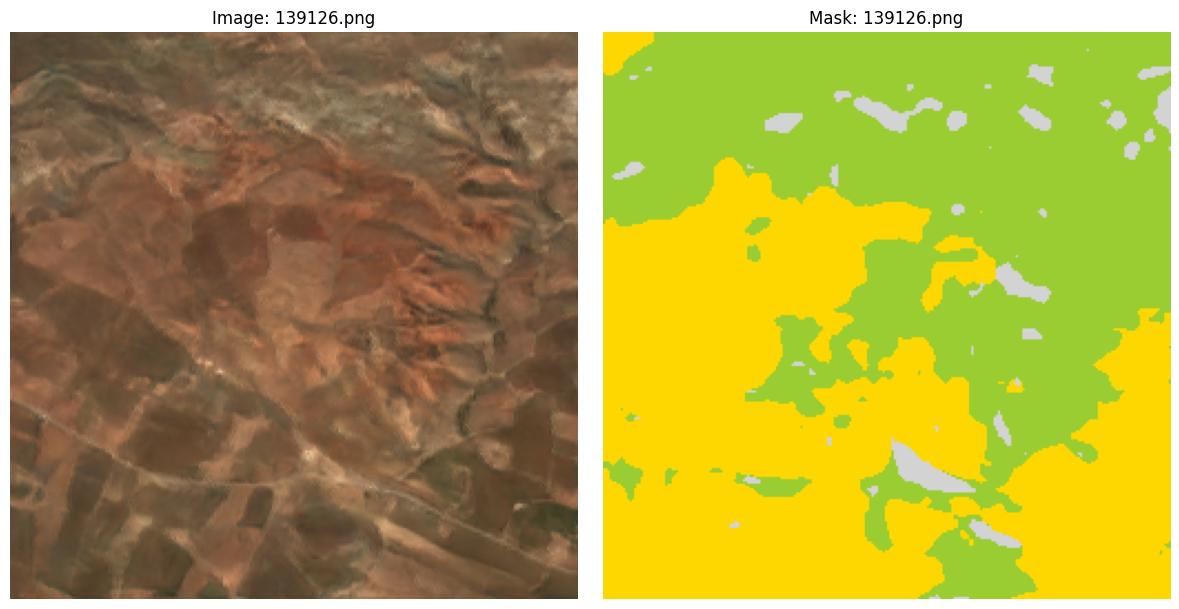

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Get a random file name
sample_file = random.choice(os.listdir(IMG_DIR))

# Define paths
img_path = os.path.join(IMG_DIR, sample_file)
mask_path = os.path.join(MASK_DIR, sample_file)

def plot_sample(img_path,mask_path):
    # Load images
    image = Image.open(img_path)
    mask = Image.open(mask_path)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image)
    axes[0].set_title(f"Image: {sample_file}")
    axes[0].axis('off')

    axes[1].imshow(mask)
    axes[1].set_title(f"Mask: {sample_file}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
plot_sample(img_path,mask_path)

In [ ]:
COLOR_MAP = {
    (0, 100, 0): 0,        # Tree
    (255, 182, 193): 1,    # Shrub
    (154, 205, 50): 2,     # Grass
    (255, 215, 0): 3,       # Crop
    (139, 69, 19): 4,      # Built-up
    (211, 211, 211): 5,    # Barren
    (0, 0, 255): 6,        # Water
}

CLASS_NAMES = {
    0: "Tree",
    1: "Shrub",
    2: "Grass",
    3: "Crop",
    4: "Built-up",
    5: "Barren",
    6: "Water"
}

# **Training**

In [ ]:
def rgb_to_class_mask(mask_img, color_map):
    """Converts the RGB mask into a 2D tensor consisting of class indices (0–6)."""
    mask_np = np.array(mask_img)
    class_mask = np.zeros((mask_np.shape[0], mask_np.shape[1]), dtype=np.int64)

    for rgb, class_idx in color_map.items():
        matches = (mask_np == rgb).all(axis=-1)
        class_mask[matches] = class_idx
    return torch.tensor(class_mask, dtype=torch.long)

In [ ]:
class MultiModalDataset(Dataset):
    def __init__(self, csv_file, img_dir, mask_dir, tokenizer, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.tokenizer = tokenizer

        # Statistics columns
        self.stat_cols = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
        # Text column
        self.text_cols = ['hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row['filename']

        # Image
        img_path = os.path.join(self.img_dir, filename)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Mask
        mask_path = os.path.join(self.mask_dir, filename)
        mask_img = Image.open(mask_path).convert("RGB")
        # Used NEAREST to prevent pixel distortion when resizing the mask
        mask_img = mask_img.resize((256, 256), Image.NEAREST)
        mask = rgb_to_class_mask(mask_img, COLOR_MAP)

        # 3. Statistics (Normalized the 0–100 range to the 0–1 range)
        stats = row[self.stat_cols].values.astype(np.float32) / 100.0
        stats = torch.tensor(stats)

        # 4. Texts (Combined 5 texts into a single sentence for the Naive Baseline)
        combined_text = " ".join([str(row[col]) for col in self.text_cols])
        text_tokens = self.tokenizer(
            combined_text,
            padding='max_length',
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        return {
            "image": image,
            "mask": mask,
            "stats": stats,
            "input_ids": text_tokens["input_ids"].squeeze(0),
            "attention_mask": text_tokens["attention_mask"].squeeze(0)
        }


In [ ]:
class TransformerBaselineModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Vision Backbone
        self.image_encoder = SegformerModel.from_pretrained("nvidia/mit-b0")
        self.vision_dim = 256 # Number of output channels in the final layer of mit-b0

        # Text Backbone
        self.text_encoder = AutoModel.from_pretrained("prajjwal1/bert-tiny")
        self.text_proj = nn.Linear(128, 64) # reducing the TinyBERT output to 64

        # Statistical Projection
        self.stat_proj = nn.Linear(7, 64)

        # Fusion Layer: Vision (256) + Text (64) + Stats (64) = 384
        self.decoder = nn.Sequential(
            nn.Conv2d(384, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, num_classes, kernel_size=1)
        )

    def forward(self, images, stats, input_ids, attention_mask):
        B, C, H, W = images.shape

        # 1. Image features
        img_outputs = self.image_encoder(pixel_values=images)
        img_features = img_outputs.last_hidden_state
        _, _, f_H, f_W = img_features.shape

        # 2. Text features -> CLS Token
        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_cls = text_outputs.last_hidden_state[:, 0, :]
        text_features = F.relu(self.text_proj(text_cls))

        # 3. Statistics Features -> [B, 64]
        stat_features = F.relu(self.stat_proj(stats))

        # 4. Spatial Expansion
        text_spatial = text_features.view(B, 64, 1, 1).expand(-1, -1, f_H, f_W)
        stat_spatial = stat_features.view(B, 64, 1, 1).expand(-1, -1, f_H, f_W)

        # 5. NAIVE FUSION
        fused = torch.cat([img_features, text_spatial, stat_spatial], dim=1) # [B, 384, f_H, f_W]

        # 6. Size dimension
        logits = self.decoder(fused) # [B, 7, f_H, f_W]

        # Restore the mask to its original image size (e.g., 256x256)
        out = F.interpolate(logits, size=(H, W), mode='bilinear', align_corners=False)
        return out

In [ ]:
def calculate_metrics(preds, masks, num_classes=7):
    """It calculates both Pixel Accuracy and mIoU values simultaneously."""
    pred_classes = torch.argmax(preds, dim=1)

    # 1. Pixel Accuracy
    correct = (pred_classes == masks).sum().item()
    total = masks.numel()
    pixel_acc = correct / total

    # 2. mIoU
    ious = []
    for cls in range(num_classes):
        pred_inds = (pred_classes == cls)
        target_inds = (masks == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = pred_inds.sum().item() + target_inds.sum().item() - intersection

        # If that class is not present at all in the ground truth of the current batch,
        #  say ‘nan’ (Not a Number) so it doesn't skew the average.
        if target_inds.sum().item() == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / max(union, 1))

    # Calculate the average of only the valid (non-zero) IoU values
    valid_ious = [iou for iou in ious if not np.isnan(iou)]
    miou = sum(valid_ious) / len(valid_ious) if valid_ious else 0.0

    return pixel_acc, miou

In [ ]:
import time
def train_and_evaluate_v2(epochs=5, batch_size=4, lr=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Devie: {device}")

    # 1. Transform, Tokenizer, and Dataloader sections have been added
    transform = T.Compose([
        T.Resize((256, 256)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    tokenizer = AutoTokenizer.from_pretrained("prajjwal1/bert-tiny")
    dataset = MultiModalDataset(CAPTION_DIR, IMG_DIR, MASK_DIR, tokenizer, transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # 2. Model Starting
    model = TransformerBaselineModel(num_classes=7).to(device)

    # 3. NEW: WEIGHTED LOSS
    # To address class imbalance, we assign a high penalty factor to rare classes.
    class_weights = torch.tensor([5.0, 5.0, 10.0, 1.0, 10.0, 10.0, 1.5]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_losses = []
    epoch_pixel_accs = []
    epoch_mious = []

    print("Advance Training (mIoU ve Weighted Loss ) Starting...")
    total_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()
        model.train()
        running_loss = 0.0
        running_pixel_acc = 0.0
        running_miou = 0.0

        for batch_idx, batch in enumerate(dataloader):
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)
            stats = batch["stats"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            optimizer.zero_grad()
            outputs = model(images, stats, input_ids, attention_mask)

            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            # We are calling our new metric function
            pixel_acc, miou = calculate_metrics(outputs, masks, 7)

            running_loss += loss.item()
            running_pixel_acc += pixel_acc
            running_miou += miou

            if (batch_idx + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{epochs}] - Batch [{batch_idx+1}/{len(dataloader)}] "
                      f"- Loss: {loss.item():.4f} - P.Acc: {pixel_acc:.4f} - mIoU: {miou:.4f}")

        avg_loss = running_loss / len(dataloader)
        avg_pixel_acc = running_pixel_acc / len(dataloader)
        avg_miou = running_miou / len(dataloader)

        epoch_losses.append(avg_loss)
        epoch_pixel_accs.append(avg_pixel_acc)
        epoch_mious.append(avg_miou)

        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time

        print(f"==> Epoch {epoch+1} summary: Loss: {avg_loss:.4f} | P.Acc: {avg_pixel_acc:.4f} | mIoU: {avg_miou:.4f} | Süre: {epoch_duration:.2f} s\n")

    total_end_time = time.time()
    print(f"Total running time: {(total_end_time - total_start_time) / 60:.2f} minute.")

    return model, dataloader, dataset, epoch_losses, epoch_pixel_accs, epoch_mious

In [ ]:

def plot_metrics(losses, accuracies):
    """
 Clean, readable, and clear charts that adhere to data-to-viz guidelines.
    """
    sns.set_theme(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(10, 5))

    color1 = '#1f77b4' # Blue
    color2 = '#d62728' # Red

    # Left Y axis: Loss
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('CrossEntropy Loss', color=color1, fontweight='bold')
    line1, = ax1.plot(range(1, len(losses)+1), losses, color=color1, marker='o', linewidth=2.5, label='Training Loss')
    ax1.tick_params(axis='y', labelcolor=color1)

    # Right Y axis: Accuracy
    ax2 = ax1.twinx()
    ax2.set_ylabel('Pixel Accuracy', color=color2, fontweight='bold')
    line2, = ax2.plot(range(1, len(accuracies)+1), accuracies, color=color2, marker='s', linewidth=2.5, linestyle='--', label='Pixel Accuracy')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('Baseline Multi-Modal Model Performance (Phase 1)', fontsize=14, fontweight='bold')

    # Legend
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right', frameon=True, shadow=True)

    plt.tight_layout()
    plt.show()



Devie: cuda


vocab.txt: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertModel LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Advance Training (mIoU ve Weighted Loss ) Starting...
Epoch [1/5] - Batch [10/2500] - Loss: 1.7757 - P.Acc: 0.2834 - mIoU: 0.1088
Epoch [1/5] - Batch [20/2500] - Loss: 1.6879 - P.Acc: 0.4535 - mIoU: 0.2290
Epoch [1/5] - Batch [30/2500] - Loss: 1.3312 - P.Acc: 0.5751 - mIoU: 0.1903
Epoch [1/5] - Batch [40/2500] - Loss: 0.7829 - P.Acc: 0.6444 - mIoU: 0.2898
Epoch [1/5] - Batch [50/2500] - Loss: 1.7439 - P.Acc: 0.5807 - mIoU: 0.1749
Epoch [1/5] - Batch [60/2500] - Loss: 1.4460 - P.Acc: 0.4236 - mIoU: 0.1762
Epoch [1/5] - Batch [70/2500] - Loss: 1.1396 - P.Acc: 0.4778 - mIoU: 0.1505
Epoch [1/5] - Batch [80/2500] - Loss: 0.9786 - P.Acc: 0.7473 - mIoU: 0.2802
Epoch [1/5] - Batch [90/2500] - Loss: 0.8110 - P.Acc: 0.8068 - mIoU: 0.3062
Epoch [1/5] - Batch [100/2500] - Loss: 1.1557 - P.Acc: 0.7158 - mIoU: 0.1898
Epoch [1/5] - Batch [110/2500] - Loss: 1.4911 - P.Acc: 0.3524 - mIoU: 0.1817
Epoch [1/5] - Batch [120/2500] - Loss: 1.1297 - P.Acc: 0.5740 - mIoU: 0.2263
Epoch [1/5] - Batch [130/2500] 

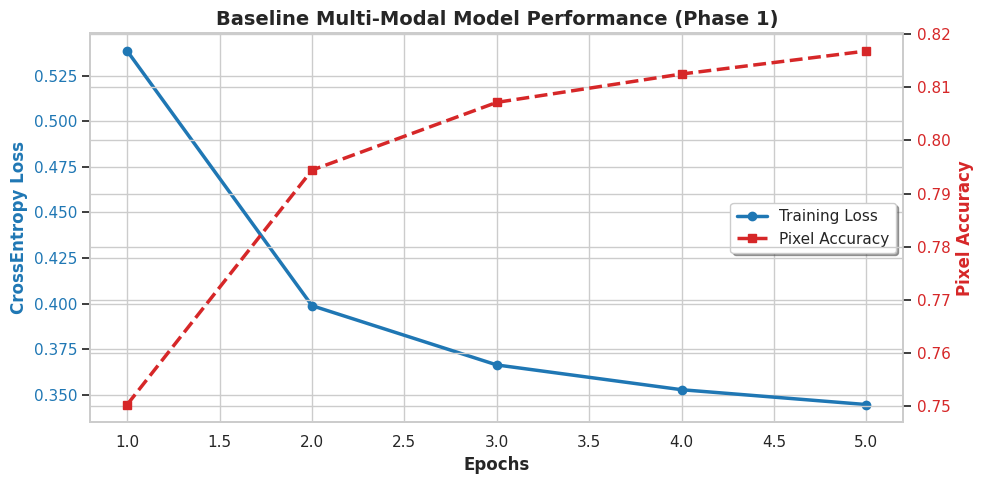

In [ ]:

if __name__ == "__main__":


    model, dataloader, dataset, epoch_losses, epoch_pixel_accs, epoch_mious = train_and_evaluate_v2(epochs=5, batch_size=4)
    plot_metrics(epoch_losses, epoch_pixel_accs)

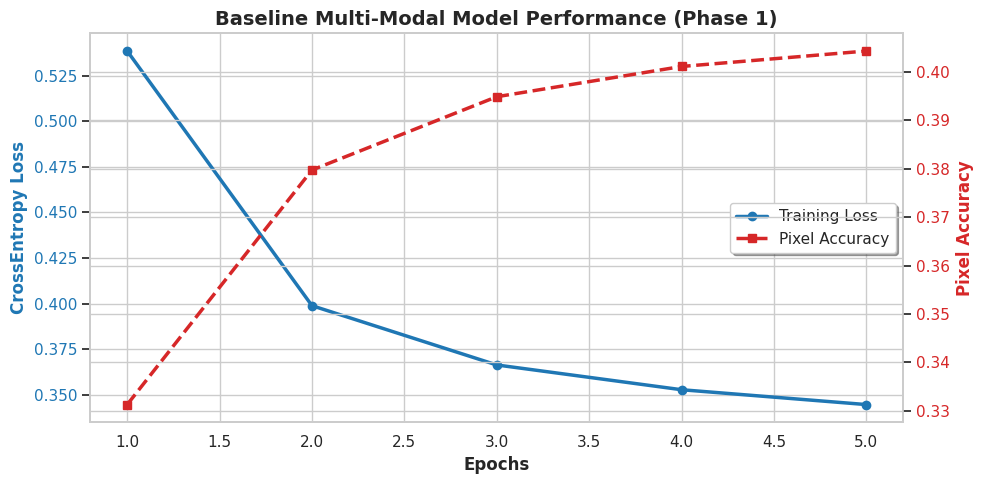

In [ ]:
plot_metrics(epoch_losses, epoch_mious) #miou

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import textwrap

REVERSE_COLOR_MAP = {v: k for k, v in COLOR_MAP.items()}

def decode_segmap(image_tensor, num_classes=7):
    image_numpy = image_tensor.cpu().numpy()
    r = np.zeros_like(image_numpy).astype(np.uint8)
    g = np.zeros_like(image_numpy).astype(np.uint8)
    b = np.zeros_like(image_numpy).astype(np.uint8)
    for class_idx in range(num_classes):
        idx = image_numpy == class_idx
        r[idx] = REVERSE_COLOR_MAP[class_idx][0]
        g[idx] = REVERSE_COLOR_MAP[class_idx][1]
        b[idx] = REVERSE_COLOR_MAP[class_idx][2]
    return np.stack([r, g, b], axis=2)

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = tensor.cpu().numpy().transpose(1, 2, 0)
    image = std * image + mean
    return np.clip(image, 0, 1)

def calculate_single_image_metrics(pred_mask, gt_mask, num_classes=7):
    """It calculates the mIoU and Acc values for only the single image displayed on the screen.."""
    ious = []
    for cls in range(num_classes):
        pred_inds = (pred_mask == cls)
        target_inds = (gt_mask == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = pred_inds.sum().item() + target_inds.sum().item() - intersection

        # If this class is present in the Ground Truth, calculate the IoU
        if target_inds.sum().item() > 0:
            ious.append(intersection / max(union, 1))

    miou = sum(ious) / len(ious) if ious else 0.0

    # Pixel Accuracy
    correct = (pred_mask == gt_mask).sum().item()
    total = gt_mask.numel()
    pixel_acc = correct / total

    return pixel_acc, miou


def visualize_complete_dashboard(model, dataloader, dataset):
    """
    Displays the model's image, statistical, and text inputs,
    along with the ground truth and predicted mask (including scores) on a single dashboard.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device)
    model.eval()

    # Retrieve a single random batch from Dataloader
    batch = next(iter(dataloader))

    # Set aside only the first element for analysis
    image = batch["image"][0].to(device)
    mask = batch["mask"][0].to(device)
    stats = batch["stats"][0].cpu().numpy() * 100
    input_ids = batch["input_ids"][0].to(device)
    attention_mask = batch["attention_mask"][0].to(device)

    with torch.no_grad():
        output = model(
            image.unsqueeze(0),
            batch["stats"][0:1].to(device),
            input_ids.unsqueeze(0),
            attention_mask.unsqueeze(0)
        )
        pred = torch.argmax(output, dim=1)[0]

    # --- NEW: Calculate the current mIoU and Acc values for the drawn image ---
    single_acc, single_miou = calculate_single_image_metrics(pred, mask, num_classes=7)

    try:
        text = dataset.tokenizer.decode(input_ids, skip_special_tokens=True)
    except:
        text = "Couldn't find"

    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(2, 3, height_ratios=[2.5, 1.2])

    # 1. Original Image
    ax_img = fig.add_subplot(gs[0, 0])
    ax_img.imshow(denormalize(image))
    ax_img.set_title("Image", fontweight='bold', fontsize=12)
    ax_img.axis('off')

    # 2. Ground Truth Mask
    ax_gt = fig.add_subplot(gs[0, 1])
    ax_gt.imshow(decode_segmap(mask))
    ax_gt.set_title("Ground Truth", fontweight='bold', fontsize=12)
    ax_gt.axis('off')

    # 3. Model Prediction with mIoU
    ax_pred = fig.add_subplot(gs[0, 2])
    ax_pred.imshow(decode_segmap(pred))

    title_str = f"Prediction\nmIoU: {single_miou*100:.1f}% | Acc: {single_acc*100:.1f}%"
    ax_pred.set_title(title_str, fontweight='bold', fontsize=12, color='darkred')
    ax_pred.axis('off')

    # 4. Statistic Bar
    ax_stat = fig.add_subplot(gs[1, 0])
    classes = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
    colors = ['#006400', '#FFB6C1', '#9ACD32', '#FFD700', '#8B4513', '#D3D3D3', '#0000FF']

    ax_stat.bar(classes, stats, color=colors, edgecolor='black', alpha=0.8)
    ax_stat.set_ylim(0, 100)
    ax_stat.set_ylabel("Percentage (%)", fontweight='bold')
    ax_stat.set_title("Class Distributions", fontweight='bold')
    ax_stat.tick_params(axis='x', rotation=30)
    ax_stat.grid(axis='y', linestyle='--', alpha=0.7)

    # 5. Text Box
    ax_text = fig.add_subplot(gs[1, 1:3])
    ax_text.axis('off')
    wrapped_text = textwrap.fill(text, width=110)

    ax_text.text(0.02, 0.5, f"Text Input (Captions):\n\n{wrapped_text}",
                 fontsize=11, va='center', ha='left', wrap=True,
                 bbox=dict(boxstyle="round,pad=1.2", fc="#f8f9fa", ec="#ced4da", lw=1.5))
    ax_text.set_title("Language Model Summary", fontweight='bold')

    plt.tight_layout()
    plt.show()

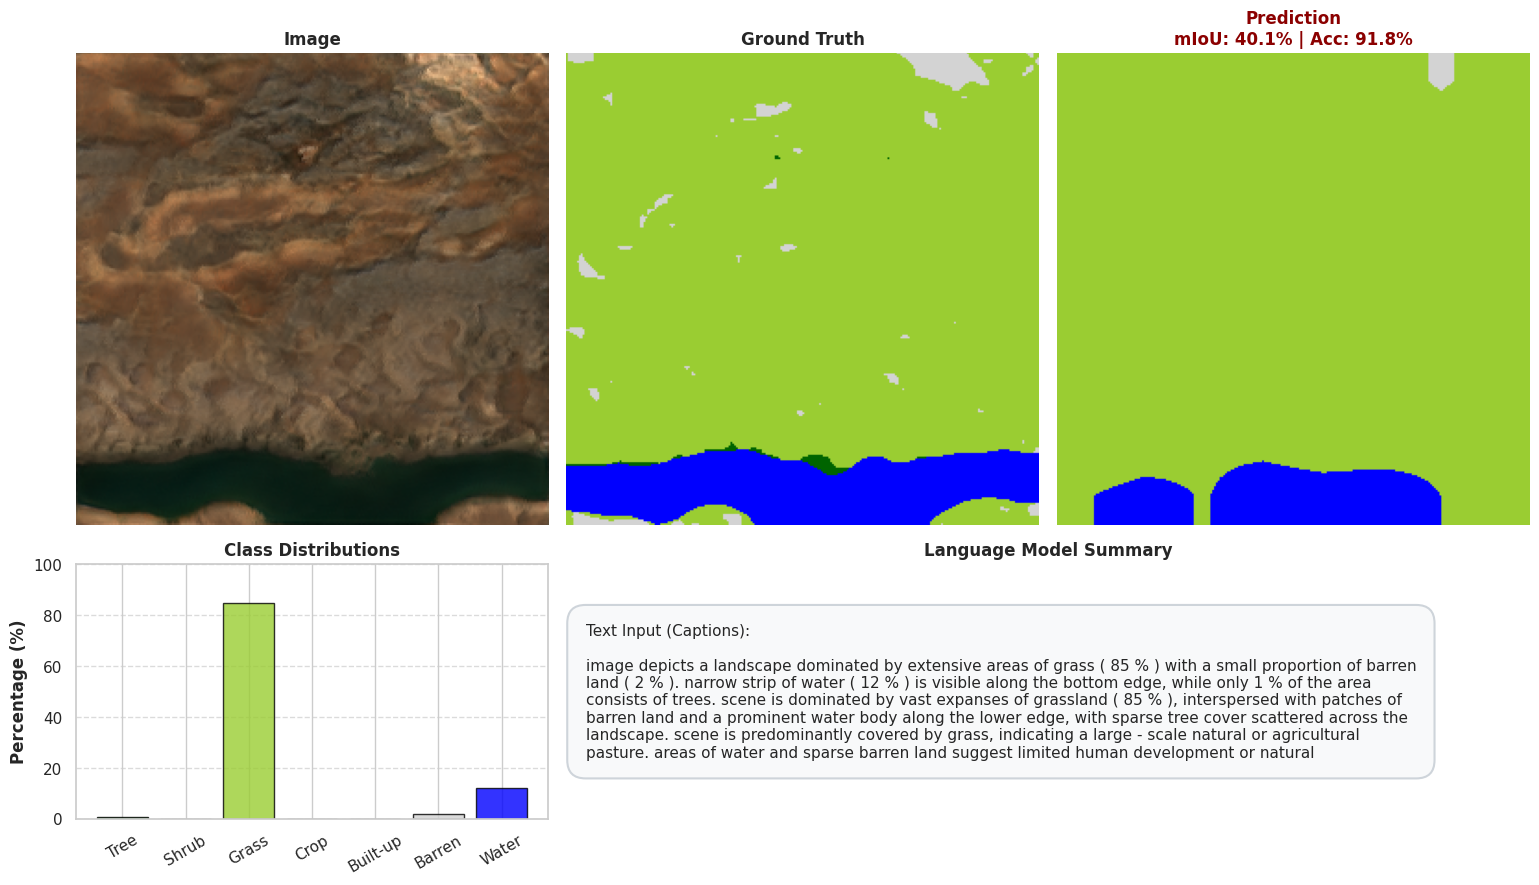

In [ ]:
# Eğer Colab'de resimler satır içi görünmüyorsa şu sihirli komutu en üste ekleyebilirsin:
# %matplotlib inline

# Fonksiyonu çağırmak (Röntgeni çekmek) için bunu mutlaka yazmalısın:
visualize_complete_dashboard(model, dataloader, dataset)

In [ ]:
import wandb
import re
wandb.login()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aleynakirmizi11 (aleynakirmizi11-middle-east-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="aleynakirmizi11-middle-east-technical-university",
    # Set the wandb project where this run will be logged.
    project="Baseline Model",
    # Track hyperparameters and run metadata.
)

In [ ]:
import wandb
import re



# 2. Elindeki BÜTÜN çıktı metnini üç tırnak arasına yapıştır
raw_logs = """
Epoch [1/5] - Batch [10/2500] - Loss: 1.7757 - P.Acc: 0.2834 - mIoU: 0.1088
Epoch [1/5] - Batch [20/2500] - Loss: 1.6879 - P.Acc: 0.4535 - mIoU: 0.2290
Epoch [1/5] - Batch [30/2500] - Loss: 1.3312 - P.Acc: 0.5751 - mIoU: 0.1903
Epoch [1/5] - Batch [40/2500] - Loss: 0.7829 - P.Acc: 0.6444 - mIoU: 0.2898
Epoch [1/5] - Batch [50/2500] - Loss: 1.7439 - P.Acc: 0.5807 - mIoU: 0.1749
Epoch [1/5] - Batch [60/2500] - Loss: 1.4460 - P.Acc: 0.4236 - mIoU: 0.1762
Epoch [1/5] - Batch [70/2500] - Loss: 1.1396 - P.Acc: 0.4778 - mIoU: 0.1505
Epoch [1/5] - Batch [80/2500] - Loss: 0.9786 - P.Acc: 0.7473 - mIoU: 0.2802
Epoch [1/5] - Batch [90/2500] - Loss: 0.8110 - P.Acc: 0.8068 - mIoU: 0.3062
Epoch [1/5] - Batch [100/2500] - Loss: 1.1557 - P.Acc: 0.7158 - mIoU: 0.1898
Epoch [1/5] - Batch [110/2500] - Loss: 1.4911 - P.Acc: 0.3524 - mIoU: 0.1817
Epoch [1/5] - Batch [120/2500] - Loss: 1.1297 - P.Acc: 0.5740 - mIoU: 0.2263
Epoch [1/5] - Batch [130/2500] - Loss: 1.0365 - P.Acc: 0.6289 - mIoU: 0.3371
Epoch [1/5] - Batch [140/2500] - Loss: 0.8290 - P.Acc: 0.8289 - mIoU: 0.3378
Epoch [1/5] - Batch [150/2500] - Loss: 0.8265 - P.Acc: 0.5286 - mIoU: 0.2065
Epoch [1/5] - Batch [160/2500] - Loss: 0.6735 - P.Acc: 0.8754 - mIoU: 0.2615
Epoch [1/5] - Batch [170/2500] - Loss: 0.6724 - P.Acc: 0.8257 - mIoU: 0.2542
Epoch [1/5] - Batch [180/2500] - Loss: 0.7296 - P.Acc: 0.7567 - mIoU: 0.2206
Epoch [1/5] - Batch [190/2500] - Loss: 0.8514 - P.Acc: 0.5368 - mIoU: 0.2020
Epoch [1/5] - Batch [200/2500] - Loss: 0.8951 - P.Acc: 0.6789 - mIoU: 0.2530
Epoch [1/5] - Batch [210/2500] - Loss: 0.8726 - P.Acc: 0.7589 - mIoU: 0.2518
Epoch [1/5] - Batch [220/2500] - Loss: 0.9417 - P.Acc: 0.6632 - mIoU: 0.2355
Epoch [1/5] - Batch [230/2500] - Loss: 0.6660 - P.Acc: 0.7271 - mIoU: 0.2282
Epoch [1/5] - Batch [240/2500] - Loss: 0.8480 - P.Acc: 0.4517 - mIoU: 0.1879
Epoch [1/5] - Batch [250/2500] - Loss: 0.9076 - P.Acc: 0.6199 - mIoU: 0.1667
Epoch [1/5] - Batch [260/2500] - Loss: 0.9292 - P.Acc: 0.5742 - mIoU: 0.2262
Epoch [1/5] - Batch [270/2500] - Loss: 0.5805 - P.Acc: 0.8286 - mIoU: 0.2065
Epoch [1/5] - Batch [280/2500] - Loss: 0.4518 - P.Acc: 0.8444 - mIoU: 0.2753
Epoch [1/5] - Batch [290/2500] - Loss: 0.5885 - P.Acc: 0.8372 - mIoU: 0.3606
Epoch [1/5] - Batch [300/2500] - Loss: 0.4269 - P.Acc: 0.9103 - mIoU: 0.3333
Epoch [1/5] - Batch [310/2500] - Loss: 0.6083 - P.Acc: 0.7315 - mIoU: 0.1982
Epoch [1/5] - Batch [320/2500] - Loss: 0.7195 - P.Acc: 0.7780 - mIoU: 0.2508
Epoch [1/5] - Batch [330/2500] - Loss: 0.5643 - P.Acc: 0.7439 - mIoU: 0.2038
Epoch [1/5] - Batch [340/2500] - Loss: 0.8412 - P.Acc: 0.6297 - mIoU: 0.2756
Epoch [1/5] - Batch [350/2500] - Loss: 0.6359 - P.Acc: 0.7196 - mIoU: 0.2082
Epoch [1/5] - Batch [360/2500] - Loss: 0.6331 - P.Acc: 0.7809 - mIoU: 0.1958
Epoch [1/5] - Batch [370/2500] - Loss: 0.6059 - P.Acc: 0.6662 - mIoU: 0.2537
Epoch [1/5] - Batch [380/2500] - Loss: 0.5392 - P.Acc: 0.5879 - mIoU: 0.1918
Epoch [1/5] - Batch [390/2500] - Loss: 0.6664 - P.Acc: 0.5655 - mIoU: 0.2273
Epoch [1/5] - Batch [400/2500] - Loss: 0.6651 - P.Acc: 0.7031 - mIoU: 0.2424
Epoch [1/5] - Batch [410/2500] - Loss: 0.4775 - P.Acc: 0.8429 - mIoU: 0.4020
Epoch [1/5] - Batch [420/2500] - Loss: 0.7753 - P.Acc: 0.5418 - mIoU: 0.1771
Epoch [1/5] - Batch [430/2500] - Loss: 0.7406 - P.Acc: 0.7476 - mIoU: 0.3009
Epoch [1/5] - Batch [440/2500] - Loss: 0.4419 - P.Acc: 0.8483 - mIoU: 0.3657
Epoch [1/5] - Batch [450/2500] - Loss: 0.7130 - P.Acc: 0.5524 - mIoU: 0.1941
Epoch [1/5] - Batch [460/2500] - Loss: 0.6993 - P.Acc: 0.6847 - mIoU: 0.3872
Epoch [1/5] - Batch [470/2500] - Loss: 0.5678 - P.Acc: 0.8716 - mIoU: 0.2689
Epoch [1/5] - Batch [480/2500] - Loss: 0.8186 - P.Acc: 0.6443 - mIoU: 0.3811
Epoch [1/5] - Batch [490/2500] - Loss: 0.5255 - P.Acc: 0.8418 - mIoU: 0.3159
Epoch [1/5] - Batch [500/2500] - Loss: 0.4503 - P.Acc: 0.8124 - mIoU: 0.3718
Epoch [1/5] - Batch [510/2500] - Loss: 0.6277 - P.Acc: 0.6473 - mIoU: 0.3000
Epoch [1/5] - Batch [520/2500] - Loss: 0.4860 - P.Acc: 0.8415 - mIoU: 0.3848
Epoch [1/5] - Batch [530/2500] - Loss: 0.7964 - P.Acc: 0.4567 - mIoU: 0.2535
Epoch [1/5] - Batch [540/2500] - Loss: 0.5224 - P.Acc: 0.8646 - mIoU: 0.3038
Epoch [1/5] - Batch [550/2500] - Loss: 0.8604 - P.Acc: 0.5779 - mIoU: 0.1328
Epoch [1/5] - Batch [560/2500] - Loss: 0.4429 - P.Acc: 0.8041 - mIoU: 0.4201
Epoch [1/5] - Batch [570/2500] - Loss: 0.3879 - P.Acc: 0.8679 - mIoU: 0.2464
Epoch [1/5] - Batch [580/2500] - Loss: 0.4249 - P.Acc: 0.7786 - mIoU: 0.4034
Epoch [1/5] - Batch [590/2500] - Loss: 0.3481 - P.Acc: 0.8375 - mIoU: 0.3184
Epoch [1/5] - Batch [600/2500] - Loss: 0.5247 - P.Acc: 0.6230 - mIoU: 0.3379
Epoch [1/5] - Batch [610/2500] - Loss: 0.4114 - P.Acc: 0.8192 - mIoU: 0.3065
Epoch [1/5] - Batch [620/2500] - Loss: 0.5330 - P.Acc: 0.7883 - mIoU: 0.2281
Epoch [1/5] - Batch [630/2500] - Loss: 0.4323 - P.Acc: 0.9013 - mIoU: 0.4216
Epoch [1/5] - Batch [640/2500] - Loss: 0.6239 - P.Acc: 0.7126 - mIoU: 0.3248
Epoch [1/5] - Batch [650/2500] - Loss: 0.9895 - P.Acc: 0.6142 - mIoU: 0.1866
Epoch [1/5] - Batch [660/2500] - Loss: 0.5923 - P.Acc: 0.6953 - mIoU: 0.3534
Epoch [1/5] - Batch [670/2500] - Loss: 0.5391 - P.Acc: 0.7505 - mIoU: 0.3710
Epoch [1/5] - Batch [680/2500] - Loss: 0.8428 - P.Acc: 0.4859 - mIoU: 0.1802
Epoch [1/5] - Batch [690/2500] - Loss: 0.4446 - P.Acc: 0.7586 - mIoU: 0.3624
Epoch [1/5] - Batch [700/2500] - Loss: 0.4637 - P.Acc: 0.7042 - mIoU: 0.2690
Epoch [1/5] - Batch [710/2500] - Loss: 0.6071 - P.Acc: 0.5875 - mIoU: 0.2626
Epoch [1/5] - Batch [720/2500] - Loss: 0.8594 - P.Acc: 0.5223 - mIoU: 0.2756
Epoch [1/5] - Batch [730/2500] - Loss: 0.6315 - P.Acc: 0.6940 - mIoU: 0.2633
Epoch [1/5] - Batch [740/2500] - Loss: 0.4885 - P.Acc: 0.7316 - mIoU: 0.4979
Epoch [1/5] - Batch [750/2500] - Loss: 0.7363 - P.Acc: 0.7147 - mIoU: 0.2516
Epoch [1/5] - Batch [760/2500] - Loss: 0.3567 - P.Acc: 0.8525 - mIoU: 0.3975
Epoch [1/5] - Batch [770/2500] - Loss: 0.4947 - P.Acc: 0.7104 - mIoU: 0.2609
Epoch [1/5] - Batch [780/2500] - Loss: 0.6506 - P.Acc: 0.6618 - mIoU: 0.2610
Epoch [1/5] - Batch [790/2500] - Loss: 0.6298 - P.Acc: 0.5492 - mIoU: 0.3151
Epoch [1/5] - Batch [800/2500] - Loss: 0.3097 - P.Acc: 0.8520 - mIoU: 0.5211
Epoch [1/5] - Batch [810/2500] - Loss: 0.5500 - P.Acc: 0.5898 - mIoU: 0.2881
Epoch [1/5] - Batch [820/2500] - Loss: 0.5624 - P.Acc: 0.7019 - mIoU: 0.2729
Epoch [1/5] - Batch [830/2500] - Loss: 0.3447 - P.Acc: 0.8283 - mIoU: 0.3046
Epoch [1/5] - Batch [840/2500] - Loss: 0.6178 - P.Acc: 0.7187 - mIoU: 0.3835
Epoch [1/5] - Batch [850/2500] - Loss: 0.7001 - P.Acc: 0.6295 - mIoU: 0.2370
Epoch [1/5] - Batch [860/2500] - Loss: 0.5075 - P.Acc: 0.8153 - mIoU: 0.3106
Epoch [1/5] - Batch [870/2500] - Loss: 0.4250 - P.Acc: 0.7976 - mIoU: 0.5246
Epoch [1/5] - Batch [880/2500] - Loss: 0.4419 - P.Acc: 0.8391 - mIoU: 0.4625
Epoch [1/5] - Batch [890/2500] - Loss: 0.4546 - P.Acc: 0.6021 - mIoU: 0.2625
Epoch [1/5] - Batch [900/2500] - Loss: 0.5149 - P.Acc: 0.7860 - mIoU: 0.3094
Epoch [1/5] - Batch [910/2500] - Loss: 0.4713 - P.Acc: 0.8071 - mIoU: 0.3686
Epoch [1/5] - Batch [920/2500] - Loss: 0.4389 - P.Acc: 0.7893 - mIoU: 0.3009
Epoch [1/5] - Batch [930/2500] - Loss: 0.4190 - P.Acc: 0.7848 - mIoU: 0.3245
Epoch [1/5] - Batch [940/2500] - Loss: 0.5657 - P.Acc: 0.7335 - mIoU: 0.2868
Epoch [1/5] - Batch [950/2500] - Loss: 0.5692 - P.Acc: 0.6716 - mIoU: 0.2576
Epoch [1/5] - Batch [960/2500] - Loss: 0.5106 - P.Acc: 0.7113 - mIoU: 0.2893
Epoch [1/5] - Batch [970/2500] - Loss: 0.6542 - P.Acc: 0.5384 - mIoU: 0.2635
Epoch [1/5] - Batch [980/2500] - Loss: 0.4084 - P.Acc: 0.8498 - mIoU: 0.2128
Epoch [1/5] - Batch [990/2500] - Loss: 0.4458 - P.Acc: 0.8047 - mIoU: 0.2465
Epoch [1/5] - Batch [1000/2500] - Loss: 0.5100 - P.Acc: 0.7239 - mIoU: 0.2842
Epoch [1/5] - Batch [1010/2500] - Loss: 0.5571 - P.Acc: 0.7341 - mIoU: 0.4226
Epoch [1/5] - Batch [1020/2500] - Loss: 0.5603 - P.Acc: 0.7880 - mIoU: 0.2334
Epoch [1/5] - Batch [1030/2500] - Loss: 0.7147 - P.Acc: 0.6844 - mIoU: 0.1808
Epoch [1/5] - Batch [1040/2500] - Loss: 0.4207 - P.Acc: 0.8328 - mIoU: 0.3234
Epoch [1/5] - Batch [1050/2500] - Loss: 0.4401 - P.Acc: 0.8691 - mIoU: 0.3912
Epoch [1/5] - Batch [1060/2500] - Loss: 0.4290 - P.Acc: 0.7093 - mIoU: 0.3280
Epoch [1/5] - Batch [1070/2500] - Loss: 0.5202 - P.Acc: 0.7868 - mIoU: 0.2460
Epoch [1/5] - Batch [1080/2500] - Loss: 0.3655 - P.Acc: 0.8619 - mIoU: 0.3989
Epoch [1/5] - Batch [1090/2500] - Loss: 0.3264 - P.Acc: 0.8637 - mIoU: 0.2583
Epoch [1/5] - Batch [1100/2500] - Loss: 0.4946 - P.Acc: 0.7674 - mIoU: 0.2680
Epoch [1/5] - Batch [1110/2500] - Loss: 0.5862 - P.Acc: 0.7869 - mIoU: 0.2372
Epoch [1/5] - Batch [1120/2500] - Loss: 0.2515 - P.Acc: 0.8130 - mIoU: 0.4209
Epoch [1/5] - Batch [1130/2500] - Loss: 0.5215 - P.Acc: 0.7484 - mIoU: 0.3861
Epoch [1/5] - Batch [1140/2500] - Loss: 0.3966 - P.Acc: 0.7554 - mIoU: 0.2560
Epoch [1/5] - Batch [1150/2500] - Loss: 0.4348 - P.Acc: 0.8493 - mIoU: 0.4582
Epoch [1/5] - Batch [1160/2500] - Loss: 0.5241 - P.Acc: 0.7603 - mIoU: 0.3619
Epoch [1/5] - Batch [1170/2500] - Loss: 0.3398 - P.Acc: 0.8085 - mIoU: 0.3201
Epoch [1/5] - Batch [1180/2500] - Loss: 0.5912 - P.Acc: 0.6370 - mIoU: 0.3172
Epoch [1/5] - Batch [1190/2500] - Loss: 0.4283 - P.Acc: 0.8140 - mIoU: 0.4083
Epoch [1/5] - Batch [1200/2500] - Loss: 0.5442 - P.Acc: 0.7214 - mIoU: 0.2816
Epoch [1/5] - Batch [1210/2500] - Loss: 0.4753 - P.Acc: 0.8166 - mIoU: 0.4917
Epoch [1/5] - Batch [1220/2500] - Loss: 0.5459 - P.Acc: 0.6882 - mIoU: 0.2681
Epoch [1/5] - Batch [1230/2500] - Loss: 0.4468 - P.Acc: 0.7729 - mIoU: 0.2948
Epoch [1/5] - Batch [1240/2500] - Loss: 0.2781 - P.Acc: 0.8449 - mIoU: 0.3136
Epoch [1/5] - Batch [1250/2500] - Loss: 0.4396 - P.Acc: 0.7778 - mIoU: 0.3149
Epoch [1/5] - Batch [1260/2500] - Loss: 0.3843 - P.Acc: 0.8398 - mIoU: 0.2534
Epoch [1/5] - Batch [1270/2500] - Loss: 0.2140 - P.Acc: 0.9282 - mIoU: 0.4592
Epoch [1/5] - Batch [1280/2500] - Loss: 0.2458 - P.Acc: 0.9148 - mIoU: 0.3836
Epoch [1/5] - Batch [1290/2500] - Loss: 0.4258 - P.Acc: 0.8351 - mIoU: 0.3282
Epoch [1/5] - Batch [1300/2500] - Loss: 0.6062 - P.Acc: 0.7361 - mIoU: 0.3598
Epoch [1/5] - Batch [1310/2500] - Loss: 0.4365 - P.Acc: 0.7800 - mIoU: 0.3018
Epoch [1/5] - Batch [1320/2500] - Loss: 0.4209 - P.Acc: 0.7536 - mIoU: 0.3379
Epoch [1/5] - Batch [1330/2500] - Loss: 0.4191 - P.Acc: 0.8721 - mIoU: 0.4962
Epoch [1/5] - Batch [1340/2500] - Loss: 0.3626 - P.Acc: 0.8790 - mIoU: 0.3239
Epoch [1/5] - Batch [1350/2500] - Loss: 0.4422 - P.Acc: 0.8217 - mIoU: 0.4303
Epoch [1/5] - Batch [1360/2500] - Loss: 0.2968 - P.Acc: 0.9085 - mIoU: 0.5261
Epoch [1/5] - Batch [1370/2500] - Loss: 0.3684 - P.Acc: 0.8080 - mIoU: 0.2880
Epoch [1/5] - Batch [1380/2500] - Loss: 0.5227 - P.Acc: 0.8335 - mIoU: 0.3461
Epoch [1/5] - Batch [1390/2500] - Loss: 0.4029 - P.Acc: 0.8060 - mIoU: 0.3577
Epoch [1/5] - Batch [1400/2500] - Loss: 0.5528 - P.Acc: 0.7952 - mIoU: 0.3391
Epoch [1/5] - Batch [1410/2500] - Loss: 0.3331 - P.Acc: 0.8600 - mIoU: 0.4594
Epoch [1/5] - Batch [1420/2500] - Loss: 0.5113 - P.Acc: 0.7449 - mIoU: 0.2828
Epoch [1/5] - Batch [1430/2500] - Loss: 0.3336 - P.Acc: 0.8232 - mIoU: 0.3513
Epoch [1/5] - Batch [1440/2500] - Loss: 0.3302 - P.Acc: 0.8666 - mIoU: 0.3641
Epoch [1/5] - Batch [1450/2500] - Loss: 0.3183 - P.Acc: 0.8727 - mIoU: 0.3350
Epoch [1/5] - Batch [1460/2500] - Loss: 0.6870 - P.Acc: 0.4726 - mIoU: 0.1863
Epoch [1/5] - Batch [1470/2500] - Loss: 0.3204 - P.Acc: 0.8535 - mIoU: 0.3393
Epoch [1/5] - Batch [1480/2500] - Loss: 0.4023 - P.Acc: 0.6854 - mIoU: 0.2751
Epoch [1/5] - Batch [1490/2500] - Loss: 0.3278 - P.Acc: 0.8943 - mIoU: 0.3243
Epoch [1/5] - Batch [1500/2500] - Loss: 0.7103 - P.Acc: 0.6185 - mIoU: 0.3417
Epoch [1/5] - Batch [1510/2500] - Loss: 0.4006 - P.Acc: 0.7681 - mIoU: 0.2593
Epoch [1/5] - Batch [1520/2500] - Loss: 0.4945 - P.Acc: 0.8137 - mIoU: 0.3747
Epoch [1/5] - Batch [1530/2500] - Loss: 0.4748 - P.Acc: 0.7322 - mIoU: 0.3418
Epoch [1/5] - Batch [1540/2500] - Loss: 0.2562 - P.Acc: 0.8877 - mIoU: 0.4116
Epoch [1/5] - Batch [1550/2500] - Loss: 0.4428 - P.Acc: 0.8086 - mIoU: 0.5103
Epoch [1/5] - Batch [1560/2500] - Loss: 0.5287 - P.Acc: 0.7655 - mIoU: 0.2387
Epoch [1/5] - Batch [1570/2500] - Loss: 0.4251 - P.Acc: 0.8640 - mIoU: 0.2614
Epoch [1/5] - Batch [1580/2500] - Loss: 0.3471 - P.Acc: 0.8386 - mIoU: 0.3279
Epoch [1/5] - Batch [1590/2500] - Loss: 0.2892 - P.Acc: 0.7192 - mIoU: 0.3399
Epoch [1/5] - Batch [1600/2500] - Loss: 0.4870 - P.Acc: 0.7261 - mIoU: 0.3701
Epoch [1/5] - Batch [1610/2500] - Loss: 0.5727 - P.Acc: 0.7964 - mIoU: 0.2695
Epoch [1/5] - Batch [1620/2500] - Loss: 0.4770 - P.Acc: 0.7531 - mIoU: 0.1932
Epoch [1/5] - Batch [1630/2500] - Loss: 0.3831 - P.Acc: 0.8844 - mIoU: 0.3739
Epoch [1/5] - Batch [1640/2500] - Loss: 0.3800 - P.Acc: 0.7758 - mIoU: 0.3944
Epoch [1/5] - Batch [1650/2500] - Loss: 0.5131 - P.Acc: 0.7080 - mIoU: 0.3623
Epoch [1/5] - Batch [1660/2500] - Loss: 0.2433 - P.Acc: 0.8837 - mIoU: 0.3225
Epoch [1/5] - Batch [1670/2500] - Loss: 0.2405 - P.Acc: 0.8931 - mIoU: 0.3792
Epoch [1/5] - Batch [1680/2500] - Loss: 0.5200 - P.Acc: 0.6998 - mIoU: 0.3057
Epoch [1/5] - Batch [1690/2500] - Loss: 0.7250 - P.Acc: 0.5995 - mIoU: 0.2929
Epoch [1/5] - Batch [1700/2500] - Loss: 0.3674 - P.Acc: 0.8120 - mIoU: 0.3784
Epoch [1/5] - Batch [1710/2500] - Loss: 0.2321 - P.Acc: 0.9052 - mIoU: 0.3400
Epoch [1/5] - Batch [1720/2500] - Loss: 0.2140 - P.Acc: 0.9030 - mIoU: 0.3506
Epoch [1/5] - Batch [1730/2500] - Loss: 0.1443 - P.Acc: 0.9460 - mIoU: 0.4992
Epoch [1/5] - Batch [1740/2500] - Loss: 0.3668 - P.Acc: 0.8749 - mIoU: 0.3155
Epoch [1/5] - Batch [1750/2500] - Loss: 0.4659 - P.Acc: 0.8077 - mIoU: 0.3129
Epoch [1/5] - Batch [1760/2500] - Loss: 0.3937 - P.Acc: 0.7589 - mIoU: 0.3937
Epoch [1/5] - Batch [1770/2500] - Loss: 0.4108 - P.Acc: 0.7627 - mIoU: 0.3556
Epoch [1/5] - Batch [1780/2500] - Loss: 0.2731 - P.Acc: 0.8739 - mIoU: 0.3361
Epoch [1/5] - Batch [1790/2500] - Loss: 0.1940 - P.Acc: 0.9188 - mIoU: 0.2640
Epoch [1/5] - Batch [1800/2500] - Loss: 0.4928 - P.Acc: 0.7548 - mIoU: 0.3034
Epoch [1/5] - Batch [1810/2500] - Loss: 0.4614 - P.Acc: 0.7488 - mIoU: 0.3746
Epoch [1/5] - Batch [1820/2500] - Loss: 0.5265 - P.Acc: 0.6832 - mIoU: 0.3533
Epoch [1/5] - Batch [1830/2500] - Loss: 0.4646 - P.Acc: 0.8169 - mIoU: 0.2409
Epoch [1/5] - Batch [1840/2500] - Loss: 0.3099 - P.Acc: 0.8302 - mIoU: 0.3343
Epoch [1/5] - Batch [1850/2500] - Loss: 0.5880 - P.Acc: 0.6092 - mIoU: 0.2178
Epoch [1/5] - Batch [1860/2500] - Loss: 0.4159 - P.Acc: 0.8263 - mIoU: 0.3191
Epoch [1/5] - Batch [1870/2500] - Loss: 0.4755 - P.Acc: 0.7144 - mIoU: 0.2848
Epoch [1/5] - Batch [1880/2500] - Loss: 0.2699 - P.Acc: 0.8889 - mIoU: 0.4242
Epoch [1/5] - Batch [1890/2500] - Loss: 0.2845 - P.Acc: 0.8693 - mIoU: 0.4489
Epoch [1/5] - Batch [1900/2500] - Loss: 0.3635 - P.Acc: 0.8686 - mIoU: 0.4065
Epoch [1/5] - Batch [1910/2500] - Loss: 0.3512 - P.Acc: 0.8447 - mIoU: 0.4016
Epoch [1/5] - Batch [1920/2500] - Loss: 0.5704 - P.Acc: 0.7167 - mIoU: 0.3657
Epoch [1/5] - Batch [1930/2500] - Loss: 0.3191 - P.Acc: 0.8706 - mIoU: 0.5367
Epoch [1/5] - Batch [1940/2500] - Loss: 0.4026 - P.Acc: 0.8963 - mIoU: 0.4940
Epoch [1/5] - Batch [1950/2500] - Loss: 0.3500 - P.Acc: 0.8585 - mIoU: 0.4817
Epoch [1/5] - Batch [1960/2500] - Loss: 0.2526 - P.Acc: 0.9079 - mIoU: 0.3538
Epoch [1/5] - Batch [1970/2500] - Loss: 0.4047 - P.Acc: 0.8190 - mIoU: 0.4565
Epoch [1/5] - Batch [1980/2500] - Loss: 0.3796 - P.Acc: 0.8427 - mIoU: 0.4520
Epoch [1/5] - Batch [1990/2500] - Loss: 0.2763 - P.Acc: 0.9097 - mIoU: 0.3069
Epoch [1/5] - Batch [2000/2500] - Loss: 0.4173 - P.Acc: 0.8433 - mIoU: 0.2658
Epoch [1/5] - Batch [2010/2500] - Loss: 0.3839 - P.Acc: 0.7999 - mIoU: 0.4365
Epoch [1/5] - Batch [2020/2500] - Loss: 0.3404 - P.Acc: 0.7885 - mIoU: 0.4050
Epoch [1/5] - Batch [2030/2500] - Loss: 0.3064 - P.Acc: 0.7715 - mIoU: 0.3011
Epoch [1/5] - Batch [2040/2500] - Loss: 0.4935 - P.Acc: 0.7282 - mIoU: 0.3872
Epoch [1/5] - Batch [2050/2500] - Loss: 0.6080 - P.Acc: 0.6835 - mIoU: 0.2143
Epoch [1/5] - Batch [2060/2500] - Loss: 0.2634 - P.Acc: 0.8600 - mIoU: 0.4492
Epoch [1/5] - Batch [2070/2500] - Loss: 0.3275 - P.Acc: 0.8862 - mIoU: 0.3280
Epoch [1/5] - Batch [2080/2500] - Loss: 0.6061 - P.Acc: 0.7245 - mIoU: 0.2202
Epoch [1/5] - Batch [2090/2500] - Loss: 0.5414 - P.Acc: 0.7370 - mIoU: 0.3438
Epoch [1/5] - Batch [2100/2500] - Loss: 0.7151 - P.Acc: 0.6858 - mIoU: 0.2817
Epoch [1/5] - Batch [2110/2500] - Loss: 0.5504 - P.Acc: 0.7646 - mIoU: 0.1892
Epoch [1/5] - Batch [2120/2500] - Loss: 0.3917 - P.Acc: 0.7690 - mIoU: 0.4357
Epoch [1/5] - Batch [2130/2500] - Loss: 0.3565 - P.Acc: 0.7584 - mIoU: 0.4835
Epoch [1/5] - Batch [2140/2500] - Loss: 0.4857 - P.Acc: 0.7206 - mIoU: 0.3899
Epoch [1/5] - Batch [2150/2500] - Loss: 0.5183 - P.Acc: 0.7012 - mIoU: 0.3222
Epoch [1/5] - Batch [2160/2500] - Loss: 0.4292 - P.Acc: 0.8112 - mIoU: 0.4817
Epoch [1/5] - Batch [2170/2500] - Loss: 0.3391 - P.Acc: 0.9028 - mIoU: 0.2826
Epoch [1/5] - Batch [2180/2500] - Loss: 0.4853 - P.Acc: 0.7249 - mIoU: 0.3724
Epoch [1/5] - Batch [2190/2500] - Loss: 0.5297 - P.Acc: 0.7668 - mIoU: 0.3425
Epoch [1/5] - Batch [2200/2500] - Loss: 0.4225 - P.Acc: 0.8936 - mIoU: 0.3205
Epoch [1/5] - Batch [2210/2500] - Loss: 0.5520 - P.Acc: 0.6638 - mIoU: 0.3725
Epoch [1/5] - Batch [2220/2500] - Loss: 0.5100 - P.Acc: 0.7665 - mIoU: 0.3859
Epoch [1/5] - Batch [2230/2500] - Loss: 0.5097 - P.Acc: 0.6754 - mIoU: 0.2856
Epoch [1/5] - Batch [2240/2500] - Loss: 0.5294 - P.Acc: 0.6884 - mIoU: 0.2847
Epoch [1/5] - Batch [2250/2500] - Loss: 0.3040 - P.Acc: 0.8804 - mIoU: 0.3369
Epoch [1/5] - Batch [2260/2500] - Loss: 0.6477 - P.Acc: 0.7022 - mIoU: 0.2461
Epoch [1/5] - Batch [2270/2500] - Loss: 0.4333 - P.Acc: 0.8319 - mIoU: 0.4242
Epoch [1/5] - Batch [2280/2500] - Loss: 0.3953 - P.Acc: 0.7528 - mIoU: 0.5107
Epoch [1/5] - Batch [2290/2500] - Loss: 0.6840 - P.Acc: 0.6937 - mIoU: 0.2757
Epoch [1/5] - Batch [2300/2500] - Loss: 0.2344 - P.Acc: 0.8267 - mIoU: 0.4983
Epoch [1/5] - Batch [2310/2500] - Loss: 0.6327 - P.Acc: 0.7439 - mIoU: 0.4025
Epoch [1/5] - Batch [2320/2500] - Loss: 0.4557 - P.Acc: 0.7264 - mIoU: 0.2503
Epoch [1/5] - Batch [2330/2500] - Loss: 0.4901 - P.Acc: 0.6800 - mIoU: 0.3185
Epoch [1/5] - Batch [2340/2500] - Loss: 0.4005 - P.Acc: 0.8299 - mIoU: 0.4078
Epoch [1/5] - Batch [2350/2500] - Loss: 0.4461 - P.Acc: 0.8197 - mIoU: 0.3107
Epoch [1/5] - Batch [2360/2500] - Loss: 0.3237 - P.Acc: 0.8642 - mIoU: 0.3931
Epoch [1/5] - Batch [2370/2500] - Loss: 0.2594 - P.Acc: 0.8478 - mIoU: 0.3930
Epoch [1/5] - Batch [2380/2500] - Loss: 0.4379 - P.Acc: 0.8521 - mIoU: 0.2526
Epoch [1/5] - Batch [2390/2500] - Loss: 0.5662 - P.Acc: 0.7015 - mIoU: 0.3264
Epoch [1/5] - Batch [2400/2500] - Loss: 0.4616 - P.Acc: 0.7913 - mIoU: 0.3489
Epoch [1/5] - Batch [2410/2500] - Loss: 0.8171 - P.Acc: 0.3829 - mIoU: 0.2664
Epoch [1/5] - Batch [2420/2500] - Loss: 0.3295 - P.Acc: 0.8352 - mIoU: 0.4788
Epoch [1/5] - Batch [2430/2500] - Loss: 0.4313 - P.Acc: 0.7772 - mIoU: 0.3512
Epoch [1/5] - Batch [2440/2500] - Loss: 0.6363 - P.Acc: 0.7932 - mIoU: 0.4801
Epoch [1/5] - Batch [2450/2500] - Loss: 0.2354 - P.Acc: 0.8841 - mIoU: 0.4123
Epoch [1/5] - Batch [2460/2500] - Loss: 0.2901 - P.Acc: 0.7674 - mIoU: 0.5830
Epoch [1/5] - Batch [2470/2500] - Loss: 0.3574 - P.Acc: 0.8791 - mIoU: 0.4626
Epoch [1/5] - Batch [2480/2500] - Loss: 0.7973 - P.Acc: 0.5740 - mIoU: 0.2203
Epoch [1/5] - Batch [2490/2500] - Loss: 0.4435 - P.Acc: 0.7737 - mIoU: 0.2942
Epoch [1/5] - Batch [2500/2500] - Loss: 0.4696 - P.Acc: 0.7018 - mIoU: 0.3062
==> Epoch 1 summary: Loss: 0.5385 | P.Acc: 0.7503 | mIoU: 0.3313 | Süre: 328.07 s

Epoch [2/5] - Batch [10/2500] - Loss: 0.3225 - P.Acc: 0.8563 - mIoU: 0.4745
Epoch [2/5] - Batch [20/2500] - Loss: 0.6885 - P.Acc: 0.7551 - mIoU: 0.1898
Epoch [2/5] - Batch [30/2500] - Loss: 0.3159 - P.Acc: 0.8026 - mIoU: 0.4061
Epoch [2/5] - Batch [40/2500] - Loss: 0.1518 - P.Acc: 0.9341 - mIoU: 0.5265
Epoch [2/5] - Batch [50/2500] - Loss: 0.2492 - P.Acc: 0.9053 - mIoU: 0.3310
Epoch [2/5] - Batch [60/2500] - Loss: 0.3148 - P.Acc: 0.6826 - mIoU: 0.3244
Epoch [2/5] - Batch [70/2500] - Loss: 0.3073 - P.Acc: 0.8247 - mIoU: 0.4697
Epoch [2/5] - Batch [80/2500] - Loss: 0.1945 - P.Acc: 0.8969 - mIoU: 0.4948
Epoch [2/5] - Batch [90/2500] - Loss: 0.4395 - P.Acc: 0.7979 - mIoU: 0.4124
Epoch [2/5] - Batch [100/2500] - Loss: 0.4260 - P.Acc: 0.8237 - mIoU: 0.2626
Epoch [2/5] - Batch [110/2500] - Loss: 0.3278 - P.Acc: 0.8130 - mIoU: 0.3061
Epoch [2/5] - Batch [120/2500] - Loss: 0.3132 - P.Acc: 0.8858 - mIoU: 0.5406
Epoch [2/5] - Batch [130/2500] - Loss: 0.6875 - P.Acc: 0.7450 - mIoU: 0.2369
Epoch [2/5] - Batch [140/2500] - Loss: 0.4855 - P.Acc: 0.8228 - mIoU: 0.4761
Epoch [2/5] - Batch [150/2500] - Loss: 0.4734 - P.Acc: 0.6993 - mIoU: 0.3124
Epoch [2/5] - Batch [160/2500] - Loss: 0.5870 - P.Acc: 0.7808 - mIoU: 0.2645
Epoch [2/5] - Batch [170/2500] - Loss: 0.3661 - P.Acc: 0.8753 - mIoU: 0.4566
Epoch [2/5] - Batch [180/2500] - Loss: 0.2357 - P.Acc: 0.8235 - mIoU: 0.4752
Epoch [2/5] - Batch [190/2500] - Loss: 0.3129 - P.Acc: 0.9156 - mIoU: 0.4199
Epoch [2/5] - Batch [200/2500] - Loss: 0.4685 - P.Acc: 0.7436 - mIoU: 0.3831
Epoch [2/5] - Batch [210/2500] - Loss: 0.3227 - P.Acc: 0.8286 - mIoU: 0.3732
Epoch [2/5] - Batch [220/2500] - Loss: 0.3256 - P.Acc: 0.8374 - mIoU: 0.3717
Epoch [2/5] - Batch [230/2500] - Loss: 0.2905 - P.Acc: 0.8092 - mIoU: 0.4256
Epoch [2/5] - Batch [240/2500] - Loss: 0.1796 - P.Acc: 0.9139 - mIoU: 0.4172
Epoch [2/5] - Batch [250/2500] - Loss: 0.6112 - P.Acc: 0.6142 - mIoU: 0.2822
Epoch [2/5] - Batch [260/2500] - Loss: 0.2691 - P.Acc: 0.8621 - mIoU: 0.4970
Epoch [2/5] - Batch [270/2500] - Loss: 0.8499 - P.Acc: 0.5183 - mIoU: 0.3147
Epoch [2/5] - Batch [280/2500] - Loss: 0.4985 - P.Acc: 0.6442 - mIoU: 0.3017
Epoch [2/5] - Batch [290/2500] - Loss: 0.4060 - P.Acc: 0.8430 - mIoU: 0.3704
Epoch [2/5] - Batch [300/2500] - Loss: 0.3617 - P.Acc: 0.8514 - mIoU: 0.3861
Epoch [2/5] - Batch [310/2500] - Loss: 0.4861 - P.Acc: 0.8157 - mIoU: 0.3275
Epoch [2/5] - Batch [320/2500] - Loss: 0.3643 - P.Acc: 0.7013 - mIoU: 0.3184
Epoch [2/5] - Batch [330/2500] - Loss: 0.2425 - P.Acc: 0.8799 - mIoU: 0.6595
Epoch [2/5] - Batch [340/2500] - Loss: 0.5724 - P.Acc: 0.7045 - mIoU: 0.3105
Epoch [2/5] - Batch [350/2500] - Loss: 0.3656 - P.Acc: 0.8162 - mIoU: 0.5001
Epoch [2/5] - Batch [360/2500] - Loss: 0.6505 - P.Acc: 0.4898 - mIoU: 0.1679
Epoch [2/5] - Batch [370/2500] - Loss: 0.1997 - P.Acc: 0.9033 - mIoU: 0.5413
Epoch [2/5] - Batch [380/2500] - Loss: 0.1849 - P.Acc: 0.9471 - mIoU: 0.4777
Epoch [2/5] - Batch [390/2500] - Loss: 0.2711 - P.Acc: 0.8300 - mIoU: 0.3267
Epoch [2/5] - Batch [400/2500] - Loss: 0.1354 - P.Acc: 0.8998 - mIoU: 0.5211
Epoch [2/5] - Batch [410/2500] - Loss: 0.3460 - P.Acc: 0.6902 - mIoU: 0.2382
Epoch [2/5] - Batch [420/2500] - Loss: 0.3003 - P.Acc: 0.8610 - mIoU: 0.2711
Epoch [2/5] - Batch [430/2500] - Loss: 0.8230 - P.Acc: 0.6087 - mIoU: 0.1864
Epoch [2/5] - Batch [440/2500] - Loss: 0.2688 - P.Acc: 0.8652 - mIoU: 0.4244
Epoch [2/5] - Batch [450/2500] - Loss: 0.3877 - P.Acc: 0.8190 - mIoU: 0.4573
Epoch [2/5] - Batch [460/2500] - Loss: 0.2086 - P.Acc: 0.9172 - mIoU: 0.3457
Epoch [2/5] - Batch [470/2500] - Loss: 0.3311 - P.Acc: 0.8347 - mIoU: 0.4779
Epoch [2/5] - Batch [480/2500] - Loss: 0.4332 - P.Acc: 0.6609 - mIoU: 0.1953
Epoch [2/5] - Batch [490/2500] - Loss: 0.3416 - P.Acc: 0.8464 - mIoU: 0.3036
Epoch [2/5] - Batch [500/2500] - Loss: 0.3031 - P.Acc: 0.8330 - mIoU: 0.3132
Epoch [2/5] - Batch [510/2500] - Loss: 0.3904 - P.Acc: 0.8520 - mIoU: 0.3732
Epoch [2/5] - Batch [520/2500] - Loss: 0.4575 - P.Acc: 0.7234 - mIoU: 0.3942
Epoch [2/5] - Batch [530/2500] - Loss: 0.5770 - P.Acc: 0.5337 - mIoU: 0.2944
Epoch [2/5] - Batch [540/2500] - Loss: 0.6365 - P.Acc: 0.6611 - mIoU: 0.2595
Epoch [2/5] - Batch [550/2500] - Loss: 0.3349 - P.Acc: 0.7326 - mIoU: 0.2870
Epoch [2/5] - Batch [560/2500] - Loss: 0.2087 - P.Acc: 0.8434 - mIoU: 0.4230
Epoch [2/5] - Batch [570/2500] - Loss: 0.1899 - P.Acc: 0.9374 - mIoU: 0.4132
Epoch [2/5] - Batch [580/2500] - Loss: 0.3258 - P.Acc: 0.8537 - mIoU: 0.4485
Epoch [2/5] - Batch [590/2500] - Loss: 0.3744 - P.Acc: 0.7840 - mIoU: 0.2579
Epoch [2/5] - Batch [600/2500] - Loss: 0.3811 - P.Acc: 0.7992 - mIoU: 0.2722
Epoch [2/5] - Batch [610/2500] - Loss: 0.4942 - P.Acc: 0.7907 - mIoU: 0.3090
Epoch [2/5] - Batch [620/2500] - Loss: 0.3574 - P.Acc: 0.8396 - mIoU: 0.2953
Epoch [2/5] - Batch [630/2500] - Loss: 0.5420 - P.Acc: 0.7371 - mIoU: 0.2658
Epoch [2/5] - Batch [640/2500] - Loss: 0.8391 - P.Acc: 0.4557 - mIoU: 0.3072
Epoch [2/5] - Batch [650/2500] - Loss: 0.2492 - P.Acc: 0.8425 - mIoU: 0.4427
Epoch [2/5] - Batch [660/2500] - Loss: 0.3759 - P.Acc: 0.8236 - mIoU: 0.3096
Epoch [2/5] - Batch [670/2500] - Loss: 0.2884 - P.Acc: 0.8457 - mIoU: 0.4359
Epoch [2/5] - Batch [680/2500] - Loss: 0.6869 - P.Acc: 0.6493 - mIoU: 0.2747
Epoch [2/5] - Batch [690/2500] - Loss: 0.1536 - P.Acc: 0.9044 - mIoU: 0.6447
Epoch [2/5] - Batch [700/2500] - Loss: 0.3516 - P.Acc: 0.8321 - mIoU: 0.3600
Epoch [2/5] - Batch [710/2500] - Loss: 0.4068 - P.Acc: 0.8261 - mIoU: 0.3762
Epoch [2/5] - Batch [720/2500] - Loss: 0.5129 - P.Acc: 0.6580 - mIoU: 0.2804
Epoch [2/5] - Batch [730/2500] - Loss: 0.5240 - P.Acc: 0.7743 - mIoU: 0.4191
Epoch [2/5] - Batch [740/2500] - Loss: 0.2410 - P.Acc: 0.8736 - mIoU: 0.4117
Epoch [2/5] - Batch [750/2500] - Loss: 0.5494 - P.Acc: 0.7978 - mIoU: 0.4851
Epoch [2/5] - Batch [760/2500] - Loss: 0.4285 - P.Acc: 0.7681 - mIoU: 0.4118
Epoch [2/5] - Batch [770/2500] - Loss: 0.3851 - P.Acc: 0.8325 - mIoU: 0.2696
Epoch [2/5] - Batch [780/2500] - Loss: 0.3168 - P.Acc: 0.8533 - mIoU: 0.5238
Epoch [2/5] - Batch [790/2500] - Loss: 0.5247 - P.Acc: 0.7470 - mIoU: 0.1930
Epoch [2/5] - Batch [800/2500] - Loss: 0.2446 - P.Acc: 0.9084 - mIoU: 0.4594
Epoch [2/5] - Batch [810/2500] - Loss: 0.2908 - P.Acc: 0.8655 - mIoU: 0.4214
Epoch [2/5] - Batch [820/2500] - Loss: 0.3854 - P.Acc: 0.7445 - mIoU: 0.4871
Epoch [2/5] - Batch [830/2500] - Loss: 0.3543 - P.Acc: 0.6764 - mIoU: 0.2756
Epoch [2/5] - Batch [840/2500] - Loss: 0.4133 - P.Acc: 0.7909 - mIoU: 0.3054
Epoch [2/5] - Batch [850/2500] - Loss: 0.3890 - P.Acc: 0.8045 - mIoU: 0.4082
Epoch [2/5] - Batch [860/2500] - Loss: 0.4072 - P.Acc: 0.7736 - mIoU: 0.2968
Epoch [2/5] - Batch [870/2500] - Loss: 0.5948 - P.Acc: 0.7522 - mIoU: 0.2094
Epoch [2/5] - Batch [880/2500] - Loss: 0.3855 - P.Acc: 0.7225 - mIoU: 0.3348
Epoch [2/5] - Batch [890/2500] - Loss: 0.6374 - P.Acc: 0.6930 - mIoU: 0.2734
Epoch [2/5] - Batch [900/2500] - Loss: 0.1342 - P.Acc: 0.9154 - mIoU: 0.6379
Epoch [2/5] - Batch [910/2500] - Loss: 0.2623 - P.Acc: 0.9151 - mIoU: 0.4239
Epoch [2/5] - Batch [920/2500] - Loss: 0.3550 - P.Acc: 0.7294 - mIoU: 0.3322
Epoch [2/5] - Batch [930/2500] - Loss: 0.4436 - P.Acc: 0.7273 - mIoU: 0.4113
Epoch [2/5] - Batch [940/2500] - Loss: 0.2858 - P.Acc: 0.9094 - mIoU: 0.4306
Epoch [2/5] - Batch [950/2500] - Loss: 0.3458 - P.Acc: 0.8704 - mIoU: 0.3385
Epoch [2/5] - Batch [960/2500] - Loss: 0.2386 - P.Acc: 0.7954 - mIoU: 0.3626
Epoch [2/5] - Batch [970/2500] - Loss: 0.4872 - P.Acc: 0.7094 - mIoU: 0.3681
Epoch [2/5] - Batch [980/2500] - Loss: 0.6408 - P.Acc: 0.7152 - mIoU: 0.5023
Epoch [2/5] - Batch [990/2500] - Loss: 0.2016 - P.Acc: 0.9288 - mIoU: 0.4187
Epoch [2/5] - Batch [1000/2500] - Loss: 0.3489 - P.Acc: 0.8367 - mIoU: 0.3586
Epoch [2/5] - Batch [1010/2500] - Loss: 0.2558 - P.Acc: 0.8950 - mIoU: 0.5819
Epoch [2/5] - Batch [1020/2500] - Loss: 0.1629 - P.Acc: 0.9379 - mIoU: 0.2979
Epoch [2/5] - Batch [1030/2500] - Loss: 0.3693 - P.Acc: 0.7572 - mIoU: 0.4062
Epoch [2/5] - Batch [1040/2500] - Loss: 0.5003 - P.Acc: 0.8128 - mIoU: 0.5065
Epoch [2/5] - Batch [1050/2500] - Loss: 0.1764 - P.Acc: 0.8521 - mIoU: 0.3569
Epoch [2/5] - Batch [1060/2500] - Loss: 0.4680 - P.Acc: 0.7993 - mIoU: 0.3500
Epoch [2/5] - Batch [1070/2500] - Loss: 0.3317 - P.Acc: 0.8565 - mIoU: 0.3752
Epoch [2/5] - Batch [1080/2500] - Loss: 0.4535 - P.Acc: 0.6652 - mIoU: 0.3523
Epoch [2/5] - Batch [1090/2500] - Loss: 0.4990 - P.Acc: 0.7326 - mIoU: 0.2441
Epoch [2/5] - Batch [1100/2500] - Loss: 0.3305 - P.Acc: 0.8616 - mIoU: 0.5084
Epoch [2/5] - Batch [1110/2500] - Loss: 0.4617 - P.Acc: 0.7486 - mIoU: 0.3505
Epoch [2/5] - Batch [1120/2500] - Loss: 0.0875 - P.Acc: 0.9522 - mIoU: 0.5925
Epoch [2/5] - Batch [1130/2500] - Loss: 0.4946 - P.Acc: 0.5785 - mIoU: 0.2663
Epoch [2/5] - Batch [1140/2500] - Loss: 0.2296 - P.Acc: 0.8330 - mIoU: 0.3158
Epoch [2/5] - Batch [1150/2500] - Loss: 0.3253 - P.Acc: 0.8278 - mIoU: 0.4918
Epoch [2/5] - Batch [1160/2500] - Loss: 0.2738 - P.Acc: 0.8762 - mIoU: 0.4867
Epoch [2/5] - Batch [1170/2500] - Loss: 0.7120 - P.Acc: 0.7126 - mIoU: 0.3304
Epoch [2/5] - Batch [1180/2500] - Loss: 0.3510 - P.Acc: 0.8649 - mIoU: 0.5994
Epoch [2/5] - Batch [1190/2500] - Loss: 0.5281 - P.Acc: 0.5781 - mIoU: 0.2933
Epoch [2/5] - Batch [1200/2500] - Loss: 0.3666 - P.Acc: 0.8000 - mIoU: 0.4330
Epoch [2/5] - Batch [1210/2500] - Loss: 0.4062 - P.Acc: 0.8580 - mIoU: 0.4641
Epoch [2/5] - Batch [1220/2500] - Loss: 0.3148 - P.Acc: 0.8870 - mIoU: 0.3461
Epoch [2/5] - Batch [1230/2500] - Loss: 0.3114 - P.Acc: 0.7580 - mIoU: 0.3148
Epoch [2/5] - Batch [1240/2500] - Loss: 0.3875 - P.Acc: 0.8404 - mIoU: 0.2911
Epoch [2/5] - Batch [1250/2500] - Loss: 0.3684 - P.Acc: 0.8570 - mIoU: 0.5230
Epoch [2/5] - Batch [1260/2500] - Loss: 0.4055 - P.Acc: 0.7980 - mIoU: 0.2237
Epoch [2/5] - Batch [1270/2500] - Loss: 0.5814 - P.Acc: 0.8198 - mIoU: 0.2535
Epoch [2/5] - Batch [1280/2500] - Loss: 0.3223 - P.Acc: 0.8459 - mIoU: 0.4131
Epoch [2/5] - Batch [1290/2500] - Loss: 0.4501 - P.Acc: 0.7561 - mIoU: 0.3192
Epoch [2/5] - Batch [1300/2500] - Loss: 0.2779 - P.Acc: 0.8072 - mIoU: 0.3855
Epoch [2/5] - Batch [1310/2500] - Loss: 0.3610 - P.Acc: 0.8001 - mIoU: 0.5456
Epoch [2/5] - Batch [1320/2500] - Loss: 0.2020 - P.Acc: 0.9081 - mIoU: 0.6362
Epoch [2/5] - Batch [1330/2500] - Loss: 0.3415 - P.Acc: 0.8208 - mIoU: 0.2500
Epoch [2/5] - Batch [1340/2500] - Loss: 0.3653 - P.Acc: 0.8429 - mIoU: 0.2998
Epoch [2/5] - Batch [1350/2500] - Loss: 0.1879 - P.Acc: 0.9348 - mIoU: 0.3585
Epoch [2/5] - Batch [1360/2500] - Loss: 0.3220 - P.Acc: 0.8399 - mIoU: 0.3511
Epoch [2/5] - Batch [1370/2500] - Loss: 0.4500 - P.Acc: 0.8069 - mIoU: 0.6633
Epoch [2/5] - Batch [1380/2500] - Loss: 0.2444 - P.Acc: 0.8581 - mIoU: 0.2565
Epoch [2/5] - Batch [1390/2500] - Loss: 0.2914 - P.Acc: 0.7840 - mIoU: 0.3820
Epoch [2/5] - Batch [1400/2500] - Loss: 0.8366 - P.Acc: 0.6097 - mIoU: 0.1636
Epoch [2/5] - Batch [1410/2500] - Loss: 0.4868 - P.Acc: 0.7707 - mIoU: 0.4009
Epoch [2/5] - Batch [1420/2500] - Loss: 0.5202 - P.Acc: 0.7004 - mIoU: 0.3866
Epoch [2/5] - Batch [1430/2500] - Loss: 0.4954 - P.Acc: 0.7212 - mIoU: 0.4400
Epoch [2/5] - Batch [1440/2500] - Loss: 0.2262 - P.Acc: 0.8868 - mIoU: 0.4483
Epoch [2/5] - Batch [1450/2500] - Loss: 0.3774 - P.Acc: 0.8217 - mIoU: 0.4497
Epoch [2/5] - Batch [1460/2500] - Loss: 0.4331 - P.Acc: 0.7659 - mIoU: 0.4384
Epoch [2/5] - Batch [1470/2500] - Loss: 0.6121 - P.Acc: 0.6947 - mIoU: 0.2544
Epoch [2/5] - Batch [1480/2500] - Loss: 0.4117 - P.Acc: 0.7083 - mIoU: 0.2047
Epoch [2/5] - Batch [1490/2500] - Loss: 0.3612 - P.Acc: 0.8139 - mIoU: 0.4205
Epoch [2/5] - Batch [1500/2500] - Loss: 0.5315 - P.Acc: 0.7442 - mIoU: 0.2204
Epoch [2/5] - Batch [1510/2500] - Loss: 0.1370 - P.Acc: 0.9541 - mIoU: 0.3705
Epoch [2/5] - Batch [1520/2500] - Loss: 0.2955 - P.Acc: 0.8761 - mIoU: 0.2727
Epoch [2/5] - Batch [1530/2500] - Loss: 0.3009 - P.Acc: 0.8708 - mIoU: 0.4777
Epoch [2/5] - Batch [1540/2500] - Loss: 0.2518 - P.Acc: 0.9100 - mIoU: 0.3206
Epoch [2/5] - Batch [1550/2500] - Loss: 0.3991 - P.Acc: 0.8447 - mIoU: 0.3569
Epoch [2/5] - Batch [1560/2500] - Loss: 0.1888 - P.Acc: 0.9505 - mIoU: 0.7271
Epoch [2/5] - Batch [1570/2500] - Loss: 0.3054 - P.Acc: 0.8231 - mIoU: 0.4118
Epoch [2/5] - Batch [1580/2500] - Loss: 0.2951 - P.Acc: 0.8509 - mIoU: 0.2967
Epoch [2/5] - Batch [1590/2500] - Loss: 0.3152 - P.Acc: 0.8818 - mIoU: 0.5083
Epoch [2/5] - Batch [1600/2500] - Loss: 0.4665 - P.Acc: 0.7806 - mIoU: 0.4035
Epoch [2/5] - Batch [1610/2500] - Loss: 0.3367 - P.Acc: 0.8331 - mIoU: 0.2980
Epoch [2/5] - Batch [1620/2500] - Loss: 0.3022 - P.Acc: 0.8424 - mIoU: 0.4490
Epoch [2/5] - Batch [1630/2500] - Loss: 0.5451 - P.Acc: 0.6198 - mIoU: 0.2050
Epoch [2/5] - Batch [1640/2500] - Loss: 0.4535 - P.Acc: 0.8246 - mIoU: 0.2307
Epoch [2/5] - Batch [1650/2500] - Loss: 0.8096 - P.Acc: 0.6185 - mIoU: 0.3800
Epoch [2/5] - Batch [1660/2500] - Loss: 0.2350 - P.Acc: 0.8642 - mIoU: 0.5703
Epoch [2/5] - Batch [1670/2500] - Loss: 0.2747 - P.Acc: 0.8582 - mIoU: 0.4500
Epoch [2/5] - Batch [1680/2500] - Loss: 0.2319 - P.Acc: 0.8819 - mIoU: 0.3730
Epoch [2/5] - Batch [1690/2500] - Loss: 0.3837 - P.Acc: 0.8202 - mIoU: 0.4770
Epoch [2/5] - Batch [1700/2500] - Loss: 0.3583 - P.Acc: 0.8539 - mIoU: 0.3161
Epoch [2/5] - Batch [1710/2500] - Loss: 0.1586 - P.Acc: 0.9484 - mIoU: 0.3058
Epoch [2/5] - Batch [1720/2500] - Loss: 0.6049 - P.Acc: 0.7322 - mIoU: 0.4026
Epoch [2/5] - Batch [1730/2500] - Loss: 0.4415 - P.Acc: 0.8323 - mIoU: 0.3929
Epoch [2/5] - Batch [1740/2500] - Loss: 0.7661 - P.Acc: 0.6830 - mIoU: 0.2992
Epoch [2/5] - Batch [1750/2500] - Loss: 0.5529 - P.Acc: 0.8129 - mIoU: 0.3372
Epoch [2/5] - Batch [1760/2500] - Loss: 0.5277 - P.Acc: 0.7721 - mIoU: 0.3360
Epoch [2/5] - Batch [1770/2500] - Loss: 0.4109 - P.Acc: 0.7727 - mIoU: 0.4031
Epoch [2/5] - Batch [1780/2500] - Loss: 0.4132 - P.Acc: 0.7375 - mIoU: 0.3717
Epoch [2/5] - Batch [1790/2500] - Loss: 0.4595 - P.Acc: 0.7806 - mIoU: 0.3571
Epoch [2/5] - Batch [1800/2500] - Loss: 0.3842 - P.Acc: 0.7590 - mIoU: 0.3817
Epoch [2/5] - Batch [1810/2500] - Loss: 0.4937 - P.Acc: 0.7317 - mIoU: 0.3509
Epoch [2/5] - Batch [1820/2500] - Loss: 0.3898 - P.Acc: 0.7629 - mIoU: 0.4759
Epoch [2/5] - Batch [1830/2500] - Loss: 0.3917 - P.Acc: 0.7672 - mIoU: 0.3068
Epoch [2/5] - Batch [1840/2500] - Loss: 0.3993 - P.Acc: 0.7389 - mIoU: 0.2632
Epoch [2/5] - Batch [1850/2500] - Loss: 0.4887 - P.Acc: 0.8385 - mIoU: 0.3935
Epoch [2/5] - Batch [1860/2500] - Loss: 0.2910 - P.Acc: 0.8412 - mIoU: 0.4682
Epoch [2/5] - Batch [1870/2500] - Loss: 0.3067 - P.Acc: 0.8020 - mIoU: 0.4008
Epoch [2/5] - Batch [1880/2500] - Loss: 0.3460 - P.Acc: 0.8735 - mIoU: 0.3924
Epoch [2/5] - Batch [1890/2500] - Loss: 0.4190 - P.Acc: 0.8179 - mIoU: 0.3188
Epoch [2/5] - Batch [1900/2500] - Loss: 0.3750 - P.Acc: 0.8216 - mIoU: 0.2680
Epoch [2/5] - Batch [1910/2500] - Loss: 0.3316 - P.Acc: 0.7875 - mIoU: 0.3504
Epoch [2/5] - Batch [1920/2500] - Loss: 0.4886 - P.Acc: 0.7664 - mIoU: 0.2877
Epoch [2/5] - Batch [1930/2500] - Loss: 0.4100 - P.Acc: 0.7833 - mIoU: 0.3553
Epoch [2/5] - Batch [1940/2500] - Loss: 0.4764 - P.Acc: 0.7859 - mIoU: 0.3867
Epoch [2/5] - Batch [1950/2500] - Loss: 0.4018 - P.Acc: 0.7642 - mIoU: 0.4334
Epoch [2/5] - Batch [1960/2500] - Loss: 0.1928 - P.Acc: 0.9313 - mIoU: 0.5323
Epoch [2/5] - Batch [1970/2500] - Loss: 0.5563 - P.Acc: 0.8011 - mIoU: 0.4086
Epoch [2/5] - Batch [1980/2500] - Loss: 0.3050 - P.Acc: 0.8786 - mIoU: 0.2631
Epoch [2/5] - Batch [1990/2500] - Loss: 0.7496 - P.Acc: 0.6811 - mIoU: 0.2787
Epoch [2/5] - Batch [2000/2500] - Loss: 0.5196 - P.Acc: 0.7555 - mIoU: 0.4818
Epoch [2/5] - Batch [2010/2500] - Loss: 0.2754 - P.Acc: 0.8790 - mIoU: 0.2562
Epoch [2/5] - Batch [2020/2500] - Loss: 0.5095 - P.Acc: 0.8059 - mIoU: 0.4644
Epoch [2/5] - Batch [2030/2500] - Loss: 0.3877 - P.Acc: 0.7656 - mIoU: 0.4207
Epoch [2/5] - Batch [2040/2500] - Loss: 0.3456 - P.Acc: 0.8496 - mIoU: 0.5681
Epoch [2/5] - Batch [2050/2500] - Loss: 0.5278 - P.Acc: 0.7577 - mIoU: 0.3133
Epoch [2/5] - Batch [2060/2500] - Loss: 0.3786 - P.Acc: 0.7991 - mIoU: 0.4287
Epoch [2/5] - Batch [2070/2500] - Loss: 0.6383 - P.Acc: 0.7393 - mIoU: 0.2645
Epoch [2/5] - Batch [2080/2500] - Loss: 0.4875 - P.Acc: 0.7874 - mIoU: 0.3110
Epoch [2/5] - Batch [2090/2500] - Loss: 0.6000 - P.Acc: 0.6026 - mIoU: 0.3581
Epoch [2/5] - Batch [2100/2500] - Loss: 0.4972 - P.Acc: 0.7866 - mIoU: 0.3449
Epoch [2/5] - Batch [2110/2500] - Loss: 0.2238 - P.Acc: 0.8810 - mIoU: 0.5946
Epoch [2/5] - Batch [2120/2500] - Loss: 0.5034 - P.Acc: 0.6549 - mIoU: 0.4654
Epoch [2/5] - Batch [2130/2500] - Loss: 0.5326 - P.Acc: 0.7850 - mIoU: 0.4967
Epoch [2/5] - Batch [2140/2500] - Loss: 0.3619 - P.Acc: 0.8079 - mIoU: 0.3782
Epoch [2/5] - Batch [2150/2500] - Loss: 0.3610 - P.Acc: 0.8448 - mIoU: 0.4253
Epoch [2/5] - Batch [2160/2500] - Loss: 0.3248 - P.Acc: 0.8246 - mIoU: 0.4385
Epoch [2/5] - Batch [2170/2500] - Loss: 0.4881 - P.Acc: 0.7087 - mIoU: 0.4249
Epoch [2/5] - Batch [2180/2500] - Loss: 0.6179 - P.Acc: 0.7264 - mIoU: 0.2262
Epoch [2/5] - Batch [2190/2500] - Loss: 0.2795 - P.Acc: 0.8470 - mIoU: 0.4915
Epoch [2/5] - Batch [2200/2500] - Loss: 0.4044 - P.Acc: 0.8643 - mIoU: 0.3612
Epoch [2/5] - Batch [2210/2500] - Loss: 0.5084 - P.Acc: 0.6168 - mIoU: 0.3454
Epoch [2/5] - Batch [2220/2500] - Loss: 0.5215 - P.Acc: 0.6711 - mIoU: 0.2620
Epoch [2/5] - Batch [2230/2500] - Loss: 0.2850 - P.Acc: 0.7950 - mIoU: 0.3182
Epoch [2/5] - Batch [2240/2500] - Loss: 0.2303 - P.Acc: 0.8841 - mIoU: 0.2804
Epoch [2/5] - Batch [2250/2500] - Loss: 0.3082 - P.Acc: 0.8181 - mIoU: 0.5517
Epoch [2/5] - Batch [2260/2500] - Loss: 0.5458 - P.Acc: 0.8206 - mIoU: 0.5185
Epoch [2/5] - Batch [2270/2500] - Loss: 0.9475 - P.Acc: 0.4053 - mIoU: 0.1417
Epoch [2/5] - Batch [2280/2500] - Loss: 0.5130 - P.Acc: 0.6587 - mIoU: 0.2837
Epoch [2/5] - Batch [2290/2500] - Loss: 0.3142 - P.Acc: 0.8967 - mIoU: 0.4813
Epoch [2/5] - Batch [2300/2500] - Loss: 0.4887 - P.Acc: 0.7855 - mIoU: 0.3655
Epoch [2/5] - Batch [2310/2500] - Loss: 0.4500 - P.Acc: 0.7401 - mIoU: 0.4414
Epoch [2/5] - Batch [2320/2500] - Loss: 0.2608 - P.Acc: 0.8807 - mIoU: 0.4195
Epoch [2/5] - Batch [2330/2500] - Loss: 0.4556 - P.Acc: 0.7673 - mIoU: 0.3608
Epoch [2/5] - Batch [2340/2500] - Loss: 0.5521 - P.Acc: 0.7564 - mIoU: 0.2633
Epoch [2/5] - Batch [2350/2500] - Loss: 0.2965 - P.Acc: 0.8509 - mIoU: 0.5026
Epoch [2/5] - Batch [2360/2500] - Loss: 0.2987 - P.Acc: 0.8954 - mIoU: 0.4265
Epoch [2/5] - Batch [2370/2500] - Loss: 0.2436 - P.Acc: 0.8498 - mIoU: 0.5654
Epoch [2/5] - Batch [2380/2500] - Loss: 0.4099 - P.Acc: 0.6418 - mIoU: 0.2780
Epoch [2/5] - Batch [2390/2500] - Loss: 0.2699 - P.Acc: 0.8984 - mIoU: 0.3433
Epoch [2/5] - Batch [2400/2500] - Loss: 0.5767 - P.Acc: 0.7521 - mIoU: 0.3005
Epoch [2/5] - Batch [2410/2500] - Loss: 0.2187 - P.Acc: 0.8731 - mIoU: 0.2681
Epoch [2/5] - Batch [2420/2500] - Loss: 0.4984 - P.Acc: 0.7648 - mIoU: 0.3560
Epoch [2/5] - Batch [2430/2500] - Loss: 0.4307 - P.Acc: 0.7076 - mIoU: 0.3116
Epoch [2/5] - Batch [2440/2500] - Loss: 0.3069 - P.Acc: 0.8435 - mIoU: 0.5067
Epoch [2/5] - Batch [2450/2500] - Loss: 0.5570 - P.Acc: 0.7288 - mIoU: 0.3130
Epoch [2/5] - Batch [2460/2500] - Loss: 0.1768 - P.Acc: 0.9405 - mIoU: 0.5543
Epoch [2/5] - Batch [2470/2500] - Loss: 0.1767 - P.Acc: 0.9392 - mIoU: 0.4435
Epoch [2/5] - Batch [2480/2500] - Loss: 0.3386 - P.Acc: 0.7892 - mIoU: 0.2621
Epoch [2/5] - Batch [2490/2500] - Loss: 0.4893 - P.Acc: 0.7767 - mIoU: 0.5180
Epoch [2/5] - Batch [2500/2500] - Loss: 0.2716 - P.Acc: 0.8480 - mIoU: 0.3496
==> Epoch 2 summary: Loss: 0.3988 | P.Acc: 0.7944 | mIoU: 0.3798 | Süre: 319.11 s

Epoch [3/5] - Batch [10/2500] - Loss: 0.3756 - P.Acc: 0.8343 - mIoU: 0.4268
Epoch [3/5] - Batch [20/2500] - Loss: 0.2961 - P.Acc: 0.8327 - mIoU: 0.3544
Epoch [3/5] - Batch [30/2500] - Loss: 0.5856 - P.Acc: 0.7715 - mIoU: 0.2904
Epoch [3/5] - Batch [40/2500] - Loss: 0.4385 - P.Acc: 0.7482 - mIoU: 0.3839
Epoch [3/5] - Batch [50/2500] - Loss: 0.5744 - P.Acc: 0.7624 - mIoU: 0.4391
Epoch [3/5] - Batch [60/2500] - Loss: 0.4941 - P.Acc: 0.7837 - mIoU: 0.4301
Epoch [3/5] - Batch [70/2500] - Loss: 0.3117 - P.Acc: 0.8630 - mIoU: 0.3392
Epoch [3/5] - Batch [80/2500] - Loss: 0.2803 - P.Acc: 0.8247 - mIoU: 0.4810
Epoch [3/5] - Batch [90/2500] - Loss: 0.3684 - P.Acc: 0.7650 - mIoU: 0.3423
Epoch [3/5] - Batch [100/2500] - Loss: 0.3594 - P.Acc: 0.8180 - mIoU: 0.4160
Epoch [3/5] - Batch [110/2500] - Loss: 0.2501 - P.Acc: 0.8340 - mIoU: 0.4584
Epoch [3/5] - Batch [120/2500] - Loss: 0.2047 - P.Acc: 0.9102 - mIoU: 0.4770
Epoch [3/5] - Batch [130/2500] - Loss: 0.2556 - P.Acc: 0.8125 - mIoU: 0.4490
Epoch [3/5] - Batch [140/2500] - Loss: 0.2847 - P.Acc: 0.8035 - mIoU: 0.4066
Epoch [3/5] - Batch [150/2500] - Loss: 0.4039 - P.Acc: 0.8213 - mIoU: 0.3760
Epoch [3/5] - Batch [160/2500] - Loss: 0.3272 - P.Acc: 0.7837 - mIoU: 0.3245
Epoch [3/5] - Batch [170/2500] - Loss: 0.3131 - P.Acc: 0.8098 - mIoU: 0.4862
Epoch [3/5] - Batch [180/2500] - Loss: 0.2547 - P.Acc: 0.8641 - mIoU: 0.4803
Epoch [3/5] - Batch [190/2500] - Loss: 0.6905 - P.Acc: 0.6689 - mIoU: 0.2919
Epoch [3/5] - Batch [200/2500] - Loss: 0.2900 - P.Acc: 0.8461 - mIoU: 0.4547
Epoch [3/5] - Batch [210/2500] - Loss: 0.3908 - P.Acc: 0.7879 - mIoU: 0.3585
Epoch [3/5] - Batch [220/2500] - Loss: 0.4017 - P.Acc: 0.7447 - mIoU: 0.4239
Epoch [3/5] - Batch [230/2500] - Loss: 0.3128 - P.Acc: 0.7876 - mIoU: 0.4451
Epoch [3/5] - Batch [240/2500] - Loss: 0.3731 - P.Acc: 0.8553 - mIoU: 0.5099
Epoch [3/5] - Batch [250/2500] - Loss: 0.3762 - P.Acc: 0.7929 - mIoU: 0.5455
Epoch [3/5] - Batch [260/2500] - Loss: 0.3951 - P.Acc: 0.8197 - mIoU: 0.2398
Epoch [3/5] - Batch [270/2500] - Loss: 0.2801 - P.Acc: 0.8100 - mIoU: 0.5308
Epoch [3/5] - Batch [280/2500] - Loss: 0.4458 - P.Acc: 0.7208 - mIoU: 0.2579
Epoch [3/5] - Batch [290/2500] - Loss: 0.2759 - P.Acc: 0.8741 - mIoU: 0.3380
Epoch [3/5] - Batch [300/2500] - Loss: 0.4081 - P.Acc: 0.8158 - mIoU: 0.3410
Epoch [3/5] - Batch [310/2500] - Loss: 0.4325 - P.Acc: 0.7659 - mIoU: 0.3606
Epoch [3/5] - Batch [320/2500] - Loss: 0.3411 - P.Acc: 0.8423 - mIoU: 0.3286
Epoch [3/5] - Batch [330/2500] - Loss: 0.4995 - P.Acc: 0.7780 - mIoU: 0.3987
Epoch [3/5] - Batch [340/2500] - Loss: 0.3894 - P.Acc: 0.7781 - mIoU: 0.3573
Epoch [3/5] - Batch [350/2500] - Loss: 0.4157 - P.Acc: 0.7546 - mIoU: 0.3768
Epoch [3/5] - Batch [360/2500] - Loss: 0.3975 - P.Acc: 0.8190 - mIoU: 0.2884
Epoch [3/5] - Batch [370/2500] - Loss: 0.4058 - P.Acc: 0.8000 - mIoU: 0.5259
Epoch [3/5] - Batch [380/2500] - Loss: 0.4270 - P.Acc: 0.8098 - mIoU: 0.4324
Epoch [3/5] - Batch [390/2500] - Loss: 0.4466 - P.Acc: 0.7424 - mIoU: 0.3528
Epoch [3/5] - Batch [400/2500] - Loss: 0.1967 - P.Acc: 0.8960 - mIoU: 0.3488
Epoch [3/5] - Batch [410/2500] - Loss: 0.3388 - P.Acc: 0.8702 - mIoU: 0.4238
Epoch [3/5] - Batch [420/2500] - Loss: 0.1376 - P.Acc: 0.9291 - mIoU: 0.6465
Epoch [3/5] - Batch [430/2500] - Loss: 0.4246 - P.Acc: 0.7990 - mIoU: 0.4542
Epoch [3/5] - Batch [440/2500] - Loss: 0.3582 - P.Acc: 0.8219 - mIoU: 0.3825
Epoch [3/5] - Batch [450/2500] - Loss: 0.4945 - P.Acc: 0.6540 - mIoU: 0.2695
Epoch [3/5] - Batch [460/2500] - Loss: 0.3006 - P.Acc: 0.8111 - mIoU: 0.3820
Epoch [3/5] - Batch [470/2500] - Loss: 0.3425 - P.Acc: 0.8447 - mIoU: 0.2944
Epoch [3/5] - Batch [480/2500] - Loss: 0.2105 - P.Acc: 0.7902 - mIoU: 0.3890
Epoch [3/5] - Batch [490/2500] - Loss: 0.2818 - P.Acc: 0.8691 - mIoU: 0.3295
Epoch [3/5] - Batch [500/2500] - Loss: 0.3466 - P.Acc: 0.8567 - mIoU: 0.3060
Epoch [3/5] - Batch [510/2500] - Loss: 0.1952 - P.Acc: 0.8738 - mIoU: 0.4430
Epoch [3/5] - Batch [520/2500] - Loss: 0.5019 - P.Acc: 0.7161 - mIoU: 0.3625
Epoch [3/5] - Batch [530/2500] - Loss: 0.2883 - P.Acc: 0.7789 - mIoU: 0.2594
Epoch [3/5] - Batch [540/2500] - Loss: 0.3704 - P.Acc: 0.7296 - mIoU: 0.3627
Epoch [3/5] - Batch [550/2500] - Loss: 0.4400 - P.Acc: 0.7934 - mIoU: 0.2457
Epoch [3/5] - Batch [560/2500] - Loss: 0.2832 - P.Acc: 0.8864 - mIoU: 0.2971
Epoch [3/5] - Batch [570/2500] - Loss: 0.4742 - P.Acc: 0.8198 - mIoU: 0.5667
Epoch [3/5] - Batch [580/2500] - Loss: 0.2747 - P.Acc: 0.8560 - mIoU: 0.3353
Epoch [3/5] - Batch [590/2500] - Loss: 0.2385 - P.Acc: 0.8145 - mIoU: 0.3448
Epoch [3/5] - Batch [600/2500] - Loss: 0.2756 - P.Acc: 0.8547 - mIoU: 0.5429
Epoch [3/5] - Batch [610/2500] - Loss: 0.2826 - P.Acc: 0.8724 - mIoU: 0.3392
Epoch [3/5] - Batch [620/2500] - Loss: 0.2724 - P.Acc: 0.8235 - mIoU: 0.4481
Epoch [3/5] - Batch [630/2500] - Loss: 0.3852 - P.Acc: 0.7445 - mIoU: 0.3409
Epoch [3/5] - Batch [640/2500] - Loss: 0.6687 - P.Acc: 0.7618 - mIoU: 0.3440
Epoch [3/5] - Batch [650/2500] - Loss: 0.2458 - P.Acc: 0.8950 - mIoU: 0.3383
Epoch [3/5] - Batch [660/2500] - Loss: 0.4505 - P.Acc: 0.8266 - mIoU: 0.4414
Epoch [3/5] - Batch [670/2500] - Loss: 0.5734 - P.Acc: 0.7896 - mIoU: 0.4077
Epoch [3/5] - Batch [680/2500] - Loss: 0.2077 - P.Acc: 0.8223 - mIoU: 0.4711
Epoch [3/5] - Batch [690/2500] - Loss: 0.4142 - P.Acc: 0.7831 - mIoU: 0.2172
Epoch [3/5] - Batch [700/2500] - Loss: 0.1594 - P.Acc: 0.8054 - mIoU: 0.5813
Epoch [3/5] - Batch [710/2500] - Loss: 0.3893 - P.Acc: 0.7272 - mIoU: 0.2583
Epoch [3/5] - Batch [720/2500] - Loss: 0.3270 - P.Acc: 0.8708 - mIoU: 0.5501
Epoch [3/5] - Batch [730/2500] - Loss: 0.3270 - P.Acc: 0.7871 - mIoU: 0.3930
Epoch [3/5] - Batch [740/2500] - Loss: 0.4578 - P.Acc: 0.7561 - mIoU: 0.3128
Epoch [3/5] - Batch [750/2500] - Loss: 0.2683 - P.Acc: 0.8623 - mIoU: 0.4333
Epoch [3/5] - Batch [760/2500] - Loss: 0.2975 - P.Acc: 0.7404 - mIoU: 0.3130
Epoch [3/5] - Batch [770/2500] - Loss: 0.1569 - P.Acc: 0.9259 - mIoU: 0.6160
Epoch [3/5] - Batch [780/2500] - Loss: 0.3203 - P.Acc: 0.8640 - mIoU: 0.4876
Epoch [3/5] - Batch [790/2500] - Loss: 0.4679 - P.Acc: 0.6536 - mIoU: 0.2558
Epoch [3/5] - Batch [800/2500] - Loss: 0.2794 - P.Acc: 0.8581 - mIoU: 0.4882
Epoch [3/5] - Batch [810/2500] - Loss: 0.3198 - P.Acc: 0.7897 - mIoU: 0.3520
Epoch [3/5] - Batch [820/2500] - Loss: 0.4306 - P.Acc: 0.8014 - mIoU: 0.3631
Epoch [3/5] - Batch [830/2500] - Loss: 0.3945 - P.Acc: 0.8143 - mIoU: 0.4111
Epoch [3/5] - Batch [840/2500] - Loss: 0.2852 - P.Acc: 0.8069 - mIoU: 0.2487
Epoch [3/5] - Batch [850/2500] - Loss: 0.3896 - P.Acc: 0.8723 - mIoU: 0.5977
Epoch [3/5] - Batch [860/2500] - Loss: 0.3149 - P.Acc: 0.8438 - mIoU: 0.2407
Epoch [3/5] - Batch [870/2500] - Loss: 0.2538 - P.Acc: 0.8216 - mIoU: 0.4088
Epoch [3/5] - Batch [880/2500] - Loss: 0.4792 - P.Acc: 0.7060 - mIoU: 0.4710
Epoch [3/5] - Batch [890/2500] - Loss: 0.6284 - P.Acc: 0.5555 - mIoU: 0.2358
Epoch [3/5] - Batch [900/2500] - Loss: 0.5020 - P.Acc: 0.7102 - mIoU: 0.3157
Epoch [3/5] - Batch [910/2500] - Loss: 0.7239 - P.Acc: 0.7172 - mIoU: 0.3721
Epoch [3/5] - Batch [920/2500] - Loss: 0.4603 - P.Acc: 0.7743 - mIoU: 0.4182
Epoch [3/5] - Batch [930/2500] - Loss: 0.3660 - P.Acc: 0.8553 - mIoU: 0.3954
Epoch [3/5] - Batch [940/2500] - Loss: 0.6105 - P.Acc: 0.6934 - mIoU: 0.4063
Epoch [3/5] - Batch [950/2500] - Loss: 0.3849 - P.Acc: 0.7232 - mIoU: 0.4221
Epoch [3/5] - Batch [960/2500] - Loss: 0.2786 - P.Acc: 0.7892 - mIoU: 0.3820
Epoch [3/5] - Batch [970/2500] - Loss: 0.2157 - P.Acc: 0.9291 - mIoU: 0.3505
Epoch [3/5] - Batch [980/2500] - Loss: 0.4443 - P.Acc: 0.7342 - mIoU: 0.4997
Epoch [3/5] - Batch [990/2500] - Loss: 0.2717 - P.Acc: 0.8733 - mIoU: 0.4039
Epoch [3/5] - Batch [1000/2500] - Loss: 0.3228 - P.Acc: 0.7193 - mIoU: 0.3489
Epoch [3/5] - Batch [1010/2500] - Loss: 0.3150 - P.Acc: 0.8429 - mIoU: 0.3065
Epoch [3/5] - Batch [1020/2500] - Loss: 0.2638 - P.Acc: 0.8359 - mIoU: 0.3605
Epoch [3/5] - Batch [1030/2500] - Loss: 0.3314 - P.Acc: 0.7544 - mIoU: 0.3381
Epoch [3/5] - Batch [1040/2500] - Loss: 0.2810 - P.Acc: 0.8698 - mIoU: 0.3375
Epoch [3/5] - Batch [1050/2500] - Loss: 0.2930 - P.Acc: 0.8825 - mIoU: 0.3995
Epoch [3/5] - Batch [1060/2500] - Loss: 0.2514 - P.Acc: 0.9069 - mIoU: 0.3703
Epoch [3/5] - Batch [1070/2500] - Loss: 0.5131 - P.Acc: 0.7460 - mIoU: 0.3735
Epoch [3/5] - Batch [1080/2500] - Loss: 0.4564 - P.Acc: 0.7805 - mIoU: 0.3343
Epoch [3/5] - Batch [1090/2500] - Loss: 0.2784 - P.Acc: 0.8844 - mIoU: 0.5313
Epoch [3/5] - Batch [1100/2500] - Loss: 0.4129 - P.Acc: 0.6899 - mIoU: 0.3009
Epoch [3/5] - Batch [1110/2500] - Loss: 0.3196 - P.Acc: 0.8209 - mIoU: 0.3398
Epoch [3/5] - Batch [1120/2500] - Loss: 0.2291 - P.Acc: 0.9102 - mIoU: 0.3979
Epoch [3/5] - Batch [1130/2500] - Loss: 0.6808 - P.Acc: 0.6119 - mIoU: 0.3656
Epoch [3/5] - Batch [1140/2500] - Loss: 0.2883 - P.Acc: 0.8338 - mIoU: 0.2739
Epoch [3/5] - Batch [1150/2500] - Loss: 0.2630 - P.Acc: 0.9071 - mIoU: 0.2232
Epoch [3/5] - Batch [1160/2500] - Loss: 0.2440 - P.Acc: 0.9004 - mIoU: 0.4465
Epoch [3/5] - Batch [1170/2500] - Loss: 0.3448 - P.Acc: 0.7676 - mIoU: 0.4347
Epoch [3/5] - Batch [1180/2500] - Loss: 0.4106 - P.Acc: 0.7749 - mIoU: 0.3092
Epoch [3/5] - Batch [1190/2500] - Loss: 0.2816 - P.Acc: 0.7328 - mIoU: 0.5033
Epoch [3/5] - Batch [1200/2500] - Loss: 0.2457 - P.Acc: 0.8250 - mIoU: 0.3278
Epoch [3/5] - Batch [1210/2500] - Loss: 0.2765 - P.Acc: 0.8703 - mIoU: 0.6190
Epoch [3/5] - Batch [1220/2500] - Loss: 0.3517 - P.Acc: 0.7969 - mIoU: 0.4014
Epoch [3/5] - Batch [1230/2500] - Loss: 0.5802 - P.Acc: 0.6388 - mIoU: 0.3382
Epoch [3/5] - Batch [1240/2500] - Loss: 0.4822 - P.Acc: 0.7741 - mIoU: 0.2885
Epoch [3/5] - Batch [1250/2500] - Loss: 0.3785 - P.Acc: 0.7954 - mIoU: 0.3878
Epoch [3/5] - Batch [1260/2500] - Loss: 0.3407 - P.Acc: 0.8493 - mIoU: 0.3641
Epoch [3/5] - Batch [1270/2500] - Loss: 0.2448 - P.Acc: 0.8516 - mIoU: 0.3893
Epoch [3/5] - Batch [1280/2500] - Loss: 0.2101 - P.Acc: 0.8423 - mIoU: 0.3299
Epoch [3/5] - Batch [1290/2500] - Loss: 0.3753 - P.Acc: 0.8042 - mIoU: 0.3849
Epoch [3/5] - Batch [1300/2500] - Loss: 0.1980 - P.Acc: 0.8706 - mIoU: 0.5121
Epoch [3/5] - Batch [1310/2500] - Loss: 0.7577 - P.Acc: 0.7151 - mIoU: 0.2972
Epoch [3/5] - Batch [1320/2500] - Loss: 0.2808 - P.Acc: 0.8115 - mIoU: 0.3316
Epoch [3/5] - Batch [1330/2500] - Loss: 0.1611 - P.Acc: 0.9536 - mIoU: 0.5477
Epoch [3/5] - Batch [1340/2500] - Loss: 0.3388 - P.Acc: 0.8096 - mIoU: 0.3778
Epoch [3/5] - Batch [1350/2500] - Loss: 0.3275 - P.Acc: 0.8314 - mIoU: 0.3316
Epoch [3/5] - Batch [1360/2500] - Loss: 0.2257 - P.Acc: 0.8603 - mIoU: 0.4130
Epoch [3/5] - Batch [1370/2500] - Loss: 0.2805 - P.Acc: 0.8713 - mIoU: 0.6953
Epoch [3/5] - Batch [1380/2500] - Loss: 0.4485 - P.Acc: 0.7903 - mIoU: 0.4640
Epoch [3/5] - Batch [1390/2500] - Loss: 0.4736 - P.Acc: 0.7116 - mIoU: 0.4465
Epoch [3/5] - Batch [1400/2500] - Loss: 0.3578 - P.Acc: 0.8287 - mIoU: 0.4864
Epoch [3/5] - Batch [1410/2500] - Loss: 0.2562 - P.Acc: 0.8930 - mIoU: 0.4111
Epoch [3/5] - Batch [1420/2500] - Loss: 0.2617 - P.Acc: 0.8079 - mIoU: 0.3574
Epoch [3/5] - Batch [1430/2500] - Loss: 0.5178 - P.Acc: 0.7590 - mIoU: 0.3037
Epoch [3/5] - Batch [1440/2500] - Loss: 0.3253 - P.Acc: 0.8608 - mIoU: 0.3497
Epoch [3/5] - Batch [1450/2500] - Loss: 0.2767 - P.Acc: 0.8720 - mIoU: 0.3997
Epoch [3/5] - Batch [1460/2500] - Loss: 0.4524 - P.Acc: 0.8174 - mIoU: 0.2976
Epoch [3/5] - Batch [1470/2500] - Loss: 0.2533 - P.Acc: 0.8293 - mIoU: 0.4051
Epoch [3/5] - Batch [1480/2500] - Loss: 0.4047 - P.Acc: 0.8539 - mIoU: 0.4585
Epoch [3/5] - Batch [1490/2500] - Loss: 0.4149 - P.Acc: 0.7707 - mIoU: 0.3193
Epoch [3/5] - Batch [1500/2500] - Loss: 0.2648 - P.Acc: 0.8507 - mIoU: 0.3730
Epoch [3/5] - Batch [1510/2500] - Loss: 0.3148 - P.Acc: 0.7575 - mIoU: 0.3418
Epoch [3/5] - Batch [1520/2500] - Loss: 0.1501 - P.Acc: 0.9514 - mIoU: 0.4506
Epoch [3/5] - Batch [1530/2500] - Loss: 0.1732 - P.Acc: 0.9286 - mIoU: 0.5380
Epoch [3/5] - Batch [1540/2500] - Loss: 0.3935 - P.Acc: 0.8435 - mIoU: 0.3758
Epoch [3/5] - Batch [1550/2500] - Loss: 0.3442 - P.Acc: 0.8194 - mIoU: 0.2757
Epoch [3/5] - Batch [1560/2500] - Loss: 0.3455 - P.Acc: 0.7816 - mIoU: 0.4151
Epoch [3/5] - Batch [1570/2500] - Loss: 0.3396 - P.Acc: 0.8381 - mIoU: 0.3671
Epoch [3/5] - Batch [1580/2500] - Loss: 0.2692 - P.Acc: 0.8597 - mIoU: 0.2438
Epoch [3/5] - Batch [1590/2500] - Loss: 0.3284 - P.Acc: 0.8629 - mIoU: 0.3975
Epoch [3/5] - Batch [1600/2500] - Loss: 0.2052 - P.Acc: 0.8801 - mIoU: 0.4865
Epoch [3/5] - Batch [1610/2500] - Loss: 0.4931 - P.Acc: 0.7126 - mIoU: 0.4415
Epoch [3/5] - Batch [1620/2500] - Loss: 0.0799 - P.Acc: 0.9745 - mIoU: 0.4434
Epoch [3/5] - Batch [1630/2500] - Loss: 0.2488 - P.Acc: 0.9228 - mIoU: 0.2694
Epoch [3/5] - Batch [1640/2500] - Loss: 0.3939 - P.Acc: 0.7316 - mIoU: 0.2913
Epoch [3/5] - Batch [1650/2500] - Loss: 0.3689 - P.Acc: 0.8211 - mIoU: 0.3727
Epoch [3/5] - Batch [1660/2500] - Loss: 0.7168 - P.Acc: 0.6787 - mIoU: 0.3334
Epoch [3/5] - Batch [1670/2500] - Loss: 0.4663 - P.Acc: 0.7781 - mIoU: 0.4057
Epoch [3/5] - Batch [1680/2500] - Loss: 0.2469 - P.Acc: 0.8936 - mIoU: 0.5626
Epoch [3/5] - Batch [1690/2500] - Loss: 0.3284 - P.Acc: 0.8791 - mIoU: 0.3870
Epoch [3/5] - Batch [1700/2500] - Loss: 0.5886 - P.Acc: 0.7873 - mIoU: 0.4001
Epoch [3/5] - Batch [1710/2500] - Loss: 0.2269 - P.Acc: 0.8985 - mIoU: 0.3525
Epoch [3/5] - Batch [1720/2500] - Loss: 0.2214 - P.Acc: 0.8435 - mIoU: 0.4950
Epoch [3/5] - Batch [1730/2500] - Loss: 0.3511 - P.Acc: 0.7922 - mIoU: 0.2751
Epoch [3/5] - Batch [1740/2500] - Loss: 0.3385 - P.Acc: 0.8375 - mIoU: 0.4355
Epoch [3/5] - Batch [1750/2500] - Loss: 0.3037 - P.Acc: 0.8674 - mIoU: 0.3076
Epoch [3/5] - Batch [1760/2500] - Loss: 0.5278 - P.Acc: 0.7029 - mIoU: 0.3772
Epoch [3/5] - Batch [1770/2500] - Loss: 0.2531 - P.Acc: 0.8802 - mIoU: 0.5094
Epoch [3/5] - Batch [1780/2500] - Loss: 0.4600 - P.Acc: 0.7529 - mIoU: 0.3596
Epoch [3/5] - Batch [1790/2500] - Loss: 0.4456 - P.Acc: 0.7445 - mIoU: 0.3805
Epoch [3/5] - Batch [1800/2500] - Loss: 0.4998 - P.Acc: 0.7801 - mIoU: 0.3879
Epoch [3/5] - Batch [1810/2500] - Loss: 0.3392 - P.Acc: 0.8249 - mIoU: 0.4396
Epoch [3/5] - Batch [1820/2500] - Loss: 0.2946 - P.Acc: 0.8277 - mIoU: 0.3803
Epoch [3/5] - Batch [1830/2500] - Loss: 0.4820 - P.Acc: 0.7517 - mIoU: 0.3479
Epoch [3/5] - Batch [1840/2500] - Loss: 0.3715 - P.Acc: 0.7934 - mIoU: 0.3539
Epoch [3/5] - Batch [1850/2500] - Loss: 0.1977 - P.Acc: 0.9193 - mIoU: 0.2852
Epoch [3/5] - Batch [1860/2500] - Loss: 0.4879 - P.Acc: 0.7432 - mIoU: 0.4268
Epoch [3/5] - Batch [1870/2500] - Loss: 0.2090 - P.Acc: 0.8857 - mIoU: 0.5098
Epoch [3/5] - Batch [1880/2500] - Loss: 0.4084 - P.Acc: 0.7343 - mIoU: 0.3435
Epoch [3/5] - Batch [1890/2500] - Loss: 0.3837 - P.Acc: 0.7971 - mIoU: 0.4249
Epoch [3/5] - Batch [1900/2500] - Loss: 0.5938 - P.Acc: 0.6215 - mIoU: 0.3789
Epoch [3/5] - Batch [1910/2500] - Loss: 0.4067 - P.Acc: 0.7106 - mIoU: 0.4143
Epoch [3/5] - Batch [1920/2500] - Loss: 0.6219 - P.Acc: 0.6462 - mIoU: 0.4033
Epoch [3/5] - Batch [1930/2500] - Loss: 0.3470 - P.Acc: 0.7793 - mIoU: 0.4548
Epoch [3/5] - Batch [1940/2500] - Loss: 0.2890 - P.Acc: 0.8936 - mIoU: 0.5348
Epoch [3/5] - Batch [1950/2500] - Loss: 0.5551 - P.Acc: 0.7279 - mIoU: 0.3554
Epoch [3/5] - Batch [1960/2500] - Loss: 0.3567 - P.Acc: 0.7672 - mIoU: 0.4742
Epoch [3/5] - Batch [1970/2500] - Loss: 0.4271 - P.Acc: 0.5738 - mIoU: 0.2248
Epoch [3/5] - Batch [1980/2500] - Loss: 0.3137 - P.Acc: 0.8743 - mIoU: 0.3431
Epoch [3/5] - Batch [1990/2500] - Loss: 0.1194 - P.Acc: 0.9601 - mIoU: 0.3575
Epoch [3/5] - Batch [2000/2500] - Loss: 0.2898 - P.Acc: 0.8387 - mIoU: 0.4125
Epoch [3/5] - Batch [2010/2500] - Loss: 0.2191 - P.Acc: 0.7927 - mIoU: 0.4294
Epoch [3/5] - Batch [2020/2500] - Loss: 0.4668 - P.Acc: 0.7360 - mIoU: 0.2954
Epoch [3/5] - Batch [2030/2500] - Loss: 0.2692 - P.Acc: 0.8786 - mIoU: 0.5123
Epoch [3/5] - Batch [2040/2500] - Loss: 0.3122 - P.Acc: 0.8355 - mIoU: 0.4438
Epoch [3/5] - Batch [2050/2500] - Loss: 0.4774 - P.Acc: 0.7022 - mIoU: 0.2950
Epoch [3/5] - Batch [2060/2500] - Loss: 0.3660 - P.Acc: 0.8423 - mIoU: 0.3118
Epoch [3/5] - Batch [2070/2500] - Loss: 0.1747 - P.Acc: 0.9143 - mIoU: 0.6253
Epoch [3/5] - Batch [2080/2500] - Loss: 0.2398 - P.Acc: 0.8550 - mIoU: 0.5754
Epoch [3/5] - Batch [2090/2500] - Loss: 0.3323 - P.Acc: 0.8131 - mIoU: 0.3883
Epoch [3/5] - Batch [2100/2500] - Loss: 0.5853 - P.Acc: 0.7718 - mIoU: 0.2779
Epoch [3/5] - Batch [2110/2500] - Loss: 0.5355 - P.Acc: 0.6961 - mIoU: 0.3163
Epoch [3/5] - Batch [2120/2500] - Loss: 0.4170 - P.Acc: 0.7932 - mIoU: 0.4433
Epoch [3/5] - Batch [2130/2500] - Loss: 0.2316 - P.Acc: 0.8729 - mIoU: 0.3228
Epoch [3/5] - Batch [2140/2500] - Loss: 0.5771 - P.Acc: 0.7437 - mIoU: 0.5577
Epoch [3/5] - Batch [2150/2500] - Loss: 0.3311 - P.Acc: 0.8185 - mIoU: 0.5286
Epoch [3/5] - Batch [2160/2500] - Loss: 0.5274 - P.Acc: 0.7941 - mIoU: 0.4216
Epoch [3/5] - Batch [2170/2500] - Loss: 0.4324 - P.Acc: 0.7739 - mIoU: 0.2776
Epoch [3/5] - Batch [2180/2500] - Loss: 0.4664 - P.Acc: 0.7932 - mIoU: 0.4747
Epoch [3/5] - Batch [2190/2500] - Loss: 0.2376 - P.Acc: 0.8779 - mIoU: 0.3764
Epoch [3/5] - Batch [2200/2500] - Loss: 0.2379 - P.Acc: 0.8781 - mIoU: 0.4575
Epoch [3/5] - Batch [2210/2500] - Loss: 0.2639 - P.Acc: 0.8731 - mIoU: 0.4795
Epoch [3/5] - Batch [2220/2500] - Loss: 0.3141 - P.Acc: 0.8391 - mIoU: 0.5231
Epoch [3/5] - Batch [2230/2500] - Loss: 0.4128 - P.Acc: 0.8131 - mIoU: 0.3830
Epoch [3/5] - Batch [2240/2500] - Loss: 0.3505 - P.Acc: 0.7886 - mIoU: 0.5633
Epoch [3/5] - Batch [2250/2500] - Loss: 0.3517 - P.Acc: 0.8135 - mIoU: 0.3669
Epoch [3/5] - Batch [2260/2500] - Loss: 0.2129 - P.Acc: 0.9125 - mIoU: 0.4392
Epoch [3/5] - Batch [2270/2500] - Loss: 0.5452 - P.Acc: 0.6886 - mIoU: 0.3680
Epoch [3/5] - Batch [2280/2500] - Loss: 0.2608 - P.Acc: 0.9152 - mIoU: 0.4125
Epoch [3/5] - Batch [2290/2500] - Loss: 0.3009 - P.Acc: 0.8289 - mIoU: 0.3206
Epoch [3/5] - Batch [2300/2500] - Loss: 0.1974 - P.Acc: 0.9247 - mIoU: 0.3708
Epoch [3/5] - Batch [2310/2500] - Loss: 0.3374 - P.Acc: 0.8705 - mIoU: 0.3874
Epoch [3/5] - Batch [2320/2500] - Loss: 0.2615 - P.Acc: 0.8677 - mIoU: 0.3609
Epoch [3/5] - Batch [2330/2500] - Loss: 0.1447 - P.Acc: 0.9431 - mIoU: 0.4138
Epoch [3/5] - Batch [2340/2500] - Loss: 0.9208 - P.Acc: 0.6867 - mIoU: 0.3810
Epoch [3/5] - Batch [2350/2500] - Loss: 0.2632 - P.Acc: 0.8918 - mIoU: 0.3526
Epoch [3/5] - Batch [2360/2500] - Loss: 0.3050 - P.Acc: 0.8404 - mIoU: 0.2440
Epoch [3/5] - Batch [2370/2500] - Loss: 0.3648 - P.Acc: 0.7698 - mIoU: 0.3480
Epoch [3/5] - Batch [2380/2500] - Loss: 0.5301 - P.Acc: 0.7310 - mIoU: 0.3040
Epoch [3/5] - Batch [2390/2500] - Loss: 0.2947 - P.Acc: 0.8781 - mIoU: 0.4427
Epoch [3/5] - Batch [2400/2500] - Loss: 0.2609 - P.Acc: 0.8888 - mIoU: 0.3805
Epoch [3/5] - Batch [2410/2500] - Loss: 0.4123 - P.Acc: 0.7701 - mIoU: 0.3328
Epoch [3/5] - Batch [2420/2500] - Loss: 0.3848 - P.Acc: 0.7959 - mIoU: 0.3658
Epoch [3/5] - Batch [2430/2500] - Loss: 0.3486 - P.Acc: 0.8278 - mIoU: 0.4266
Epoch [3/5] - Batch [2440/2500] - Loss: 0.2637 - P.Acc: 0.8170 - mIoU: 0.4662
Epoch [3/5] - Batch [2450/2500] - Loss: 0.4861 - P.Acc: 0.6845 - mIoU: 0.3354
Epoch [3/5] - Batch [2460/2500] - Loss: 0.3907 - P.Acc: 0.7692 - mIoU: 0.2911
Epoch [3/5] - Batch [2470/2500] - Loss: 0.3474 - P.Acc: 0.8223 - mIoU: 0.3755
Epoch [3/5] - Batch [2480/2500] - Loss: 0.4153 - P.Acc: 0.7135 - mIoU: 0.3395
Epoch [3/5] - Batch [2490/2500] - Loss: 0.5032 - P.Acc: 0.7816 - mIoU: 0.4370
Epoch [3/5] - Batch [2500/2500] - Loss: 0.2153 - P.Acc: 0.9022 - mIoU: 0.3417
==> Epoch 3 summary: Loss: 0.3663 | P.Acc: 0.8071 | mIoU: 0.3949 | Süre: 318.45 s

Epoch [4/5] - Batch [10/2500] - Loss: 0.3000 - P.Acc: 0.7830 - mIoU: 0.5176
Epoch [4/5] - Batch [20/2500] - Loss: 0.5632 - P.Acc: 0.6883 - mIoU: 0.4041
Epoch [4/5] - Batch [30/2500] - Loss: 0.5115 - P.Acc: 0.7710 - mIoU: 0.2724
Epoch [4/5] - Batch [40/2500] - Loss: 0.2768 - P.Acc: 0.8536 - mIoU: 0.4358
Epoch [4/5] - Batch [50/2500] - Loss: 0.4475 - P.Acc: 0.7458 - mIoU: 0.3758
Epoch [4/5] - Batch [60/2500] - Loss: 0.1830 - P.Acc: 0.8572 - mIoU: 0.5009
Epoch [4/5] - Batch [70/2500] - Loss: 0.2887 - P.Acc: 0.8893 - mIoU: 0.3029
Epoch [4/5] - Batch [80/2500] - Loss: 0.3567 - P.Acc: 0.8156 - mIoU: 0.3803
Epoch [4/5] - Batch [90/2500] - Loss: 0.2292 - P.Acc: 0.9055 - mIoU: 0.3253
Epoch [4/5] - Batch [100/2500] - Loss: 0.3055 - P.Acc: 0.7753 - mIoU: 0.3586
Epoch [4/5] - Batch [110/2500] - Loss: 0.4121 - P.Acc: 0.8013 - mIoU: 0.4319
Epoch [4/5] - Batch [120/2500] - Loss: 0.3432 - P.Acc: 0.7735 - mIoU: 0.3662
Epoch [4/5] - Batch [130/2500] - Loss: 0.5133 - P.Acc: 0.7478 - mIoU: 0.2822
Epoch [4/5] - Batch [140/2500] - Loss: 0.2437 - P.Acc: 0.9190 - mIoU: 0.5712
Epoch [4/5] - Batch [150/2500] - Loss: 0.4169 - P.Acc: 0.8011 - mIoU: 0.4802
Epoch [4/5] - Batch [160/2500] - Loss: 0.5021 - P.Acc: 0.7409 - mIoU: 0.2913
Epoch [4/5] - Batch [170/2500] - Loss: 0.2516 - P.Acc: 0.7665 - mIoU: 0.3237
Epoch [4/5] - Batch [180/2500] - Loss: 0.1827 - P.Acc: 0.8942 - mIoU: 0.5027
Epoch [4/5] - Batch [190/2500] - Loss: 0.4145 - P.Acc: 0.7348 - mIoU: 0.3841
Epoch [4/5] - Batch [200/2500] - Loss: 0.4310 - P.Acc: 0.8129 - mIoU: 0.3817
Epoch [4/5] - Batch [210/2500] - Loss: 0.3126 - P.Acc: 0.8494 - mIoU: 0.4652
Epoch [4/5] - Batch [220/2500] - Loss: 0.2316 - P.Acc: 0.9009 - mIoU: 0.3288
Epoch [4/5] - Batch [230/2500] - Loss: 0.2575 - P.Acc: 0.8870 - mIoU: 0.5197
Epoch [4/5] - Batch [240/2500] - Loss: 0.3702 - P.Acc: 0.8166 - mIoU: 0.3223
Epoch [4/5] - Batch [250/2500] - Loss: 0.2236 - P.Acc: 0.8735 - mIoU: 0.4725
Epoch [4/5] - Batch [260/2500] - Loss: 0.3470 - P.Acc: 0.8474 - mIoU: 0.5804
Epoch [4/5] - Batch [270/2500] - Loss: 0.2821 - P.Acc: 0.8192 - mIoU: 0.3604
Epoch [4/5] - Batch [280/2500] - Loss: 0.3811 - P.Acc: 0.7941 - mIoU: 0.2376
Epoch [4/5] - Batch [290/2500] - Loss: 0.4452 - P.Acc: 0.8633 - mIoU: 0.2949
Epoch [4/5] - Batch [300/2500] - Loss: 0.3242 - P.Acc: 0.8552 - mIoU: 0.4443
Epoch [4/5] - Batch [310/2500] - Loss: 0.1775 - P.Acc: 0.9202 - mIoU: 0.4653
Epoch [4/5] - Batch [320/2500] - Loss: 0.3938 - P.Acc: 0.7669 - mIoU: 0.4353
Epoch [4/5] - Batch [330/2500] - Loss: 0.1840 - P.Acc: 0.9035 - mIoU: 0.4167
Epoch [4/5] - Batch [340/2500] - Loss: 0.3225 - P.Acc: 0.8415 - mIoU: 0.5087
Epoch [4/5] - Batch [350/2500] - Loss: 0.4145 - P.Acc: 0.8213 - mIoU: 0.3785
Epoch [4/5] - Batch [360/2500] - Loss: 0.4088 - P.Acc: 0.8008 - mIoU: 0.5401
Epoch [4/5] - Batch [370/2500] - Loss: 0.2594 - P.Acc: 0.8508 - mIoU: 0.3685
Epoch [4/5] - Batch [380/2500] - Loss: 0.2713 - P.Acc: 0.8515 - mIoU: 0.2150
Epoch [4/5] - Batch [390/2500] - Loss: 0.2763 - P.Acc: 0.8960 - mIoU: 0.5159
Epoch [4/5] - Batch [400/2500] - Loss: 0.1832 - P.Acc: 0.8752 - mIoU: 0.4884
Epoch [4/5] - Batch [410/2500] - Loss: 0.3644 - P.Acc: 0.8074 - mIoU: 0.4047
Epoch [4/5] - Batch [420/2500] - Loss: 0.4406 - P.Acc: 0.6588 - mIoU: 0.3123
Epoch [4/5] - Batch [430/2500] - Loss: 0.4164 - P.Acc: 0.8221 - mIoU: 0.4035
Epoch [4/5] - Batch [440/2500] - Loss: 0.2185 - P.Acc: 0.8826 - mIoU: 0.2872
Epoch [4/5] - Batch [450/2500] - Loss: 0.3481 - P.Acc: 0.8540 - mIoU: 0.5686
Epoch [4/5] - Batch [460/2500] - Loss: 0.3320 - P.Acc: 0.8050 - mIoU: 0.3233
Epoch [4/5] - Batch [470/2500] - Loss: 0.3182 - P.Acc: 0.8384 - mIoU: 0.5597
Epoch [4/5] - Batch [480/2500] - Loss: 0.2081 - P.Acc: 0.8384 - mIoU: 0.3748
Epoch [4/5] - Batch [490/2500] - Loss: 0.1899 - P.Acc: 0.9293 - mIoU: 0.5302
Epoch [4/5] - Batch [500/2500] - Loss: 0.3989 - P.Acc: 0.7642 - mIoU: 0.5267
Epoch [4/5] - Batch [510/2500] - Loss: 0.4083 - P.Acc: 0.7606 - mIoU: 0.3347
Epoch [4/5] - Batch [520/2500] - Loss: 0.3376 - P.Acc: 0.8548 - mIoU: 0.3509
Epoch [4/5] - Batch [530/2500] - Loss: 0.4802 - P.Acc: 0.7174 - mIoU: 0.3141
Epoch [4/5] - Batch [540/2500] - Loss: 0.2760 - P.Acc: 0.8658 - mIoU: 0.3011
Epoch [4/5] - Batch [550/2500] - Loss: 0.2492 - P.Acc: 0.8450 - mIoU: 0.3116
Epoch [4/5] - Batch [560/2500] - Loss: 0.4306 - P.Acc: 0.7809 - mIoU: 0.3862
Epoch [4/5] - Batch [570/2500] - Loss: 0.2483 - P.Acc: 0.8921 - mIoU: 0.5206
Epoch [4/5] - Batch [580/2500] - Loss: 0.3638 - P.Acc: 0.7771 - mIoU: 0.4306
Epoch [4/5] - Batch [590/2500] - Loss: 0.3081 - P.Acc: 0.8657 - mIoU: 0.3660
Epoch [4/5] - Batch [600/2500] - Loss: 0.2424 - P.Acc: 0.8885 - mIoU: 0.4559
Epoch [4/5] - Batch [610/2500] - Loss: 0.2069 - P.Acc: 0.8290 - mIoU: 0.3559
Epoch [4/5] - Batch [620/2500] - Loss: 0.3041 - P.Acc: 0.8626 - mIoU: 0.4584
Epoch [4/5] - Batch [630/2500] - Loss: 0.3511 - P.Acc: 0.7406 - mIoU: 0.3314
Epoch [4/5] - Batch [640/2500] - Loss: 0.3033 - P.Acc: 0.8394 - mIoU: 0.4224
Epoch [4/5] - Batch [650/2500] - Loss: 0.4646 - P.Acc: 0.7902 - mIoU: 0.3337
Epoch [4/5] - Batch [660/2500] - Loss: 0.2077 - P.Acc: 0.9038 - mIoU: 0.3527
Epoch [4/5] - Batch [670/2500] - Loss: 0.5432 - P.Acc: 0.7492 - mIoU: 0.3233
Epoch [4/5] - Batch [680/2500] - Loss: 0.2220 - P.Acc: 0.8310 - mIoU: 0.3593
Epoch [4/5] - Batch [690/2500] - Loss: 0.1875 - P.Acc: 0.9203 - mIoU: 0.5401
Epoch [4/5] - Batch [700/2500] - Loss: 0.3612 - P.Acc: 0.6666 - mIoU: 0.3922
Epoch [4/5] - Batch [710/2500] - Loss: 0.2325 - P.Acc: 0.9044 - mIoU: 0.6110
Epoch [4/5] - Batch [720/2500] - Loss: 0.2762 - P.Acc: 0.8662 - mIoU: 0.3814
Epoch [4/5] - Batch [730/2500] - Loss: 0.2224 - P.Acc: 0.8407 - mIoU: 0.3580
Epoch [4/5] - Batch [740/2500] - Loss: 0.2864 - P.Acc: 0.9267 - mIoU: 0.4330
Epoch [4/5] - Batch [750/2500] - Loss: 0.4736 - P.Acc: 0.7356 - mIoU: 0.2390
Epoch [4/5] - Batch [760/2500] - Loss: 0.2360 - P.Acc: 0.8930 - mIoU: 0.4763
Epoch [4/5] - Batch [770/2500] - Loss: 0.3307 - P.Acc: 0.8301 - mIoU: 0.3888
Epoch [4/5] - Batch [780/2500] - Loss: 0.5028 - P.Acc: 0.7256 - mIoU: 0.5734
Epoch [4/5] - Batch [790/2500] - Loss: 0.3322 - P.Acc: 0.7958 - mIoU: 0.4018
Epoch [4/5] - Batch [800/2500] - Loss: 0.3178 - P.Acc: 0.8185 - mIoU: 0.3576
Epoch [4/5] - Batch [810/2500] - Loss: 0.3068 - P.Acc: 0.8512 - mIoU: 0.3866
Epoch [4/5] - Batch [820/2500] - Loss: 0.2770 - P.Acc: 0.8767 - mIoU: 0.2604
Epoch [4/5] - Batch [830/2500] - Loss: 0.5043 - P.Acc: 0.5990 - mIoU: 0.4252
Epoch [4/5] - Batch [840/2500] - Loss: 0.3579 - P.Acc: 0.8268 - mIoU: 0.2656
Epoch [4/5] - Batch [850/2500] - Loss: 0.3835 - P.Acc: 0.8324 - mIoU: 0.5179
Epoch [4/5] - Batch [860/2500] - Loss: 0.2966 - P.Acc: 0.8332 - mIoU: 0.4968
Epoch [4/5] - Batch [870/2500] - Loss: 0.3140 - P.Acc: 0.8917 - mIoU: 0.4523
Epoch [4/5] - Batch [880/2500] - Loss: 0.3009 - P.Acc: 0.8257 - mIoU: 0.4526
Epoch [4/5] - Batch [890/2500] - Loss: 0.4370 - P.Acc: 0.7709 - mIoU: 0.3178
Epoch [4/5] - Batch [900/2500] - Loss: 0.1627 - P.Acc: 0.9013 - mIoU: 0.3774
Epoch [4/5] - Batch [910/2500] - Loss: 0.2255 - P.Acc: 0.8239 - mIoU: 0.3062
Epoch [4/5] - Batch [920/2500] - Loss: 0.4033 - P.Acc: 0.6926 - mIoU: 0.2866
Epoch [4/5] - Batch [930/2500] - Loss: 0.4809 - P.Acc: 0.7510 - mIoU: 0.4299
Epoch [4/5] - Batch [940/2500] - Loss: 0.4373 - P.Acc: 0.8009 - mIoU: 0.3711
Epoch [4/5] - Batch [950/2500] - Loss: 0.3099 - P.Acc: 0.8155 - mIoU: 0.5090
Epoch [4/5] - Batch [960/2500] - Loss: 0.3956 - P.Acc: 0.7376 - mIoU: 0.2897
Epoch [4/5] - Batch [970/2500] - Loss: 0.3516 - P.Acc: 0.8015 - mIoU: 0.3311
Epoch [4/5] - Batch [980/2500] - Loss: 0.4854 - P.Acc: 0.7056 - mIoU: 0.4153
Epoch [4/5] - Batch [990/2500] - Loss: 0.2423 - P.Acc: 0.8461 - mIoU: 0.3760
Epoch [4/5] - Batch [1000/2500] - Loss: 0.3010 - P.Acc: 0.8351 - mIoU: 0.4310
Epoch [4/5] - Batch [1010/2500] - Loss: 0.2469 - P.Acc: 0.8225 - mIoU: 0.3028
Epoch [4/5] - Batch [1020/2500] - Loss: 0.4162 - P.Acc: 0.7400 - mIoU: 0.2617
Epoch [4/5] - Batch [1030/2500] - Loss: 0.4200 - P.Acc: 0.7755 - mIoU: 0.3811
Epoch [4/5] - Batch [1040/2500] - Loss: 0.5015 - P.Acc: 0.7942 - mIoU: 0.3607
Epoch [4/5] - Batch [1050/2500] - Loss: 0.4100 - P.Acc: 0.7784 - mIoU: 0.3500
Epoch [4/5] - Batch [1060/2500] - Loss: 0.1951 - P.Acc: 0.8632 - mIoU: 0.4719
Epoch [4/5] - Batch [1070/2500] - Loss: 0.2457 - P.Acc: 0.8931 - mIoU: 0.3980
Epoch [4/5] - Batch [1080/2500] - Loss: 0.3686 - P.Acc: 0.8517 - mIoU: 0.4746
Epoch [4/5] - Batch [1090/2500] - Loss: 0.3972 - P.Acc: 0.8101 - mIoU: 0.3043
Epoch [4/5] - Batch [1100/2500] - Loss: 0.4337 - P.Acc: 0.7306 - mIoU: 0.2732
Epoch [4/5] - Batch [1110/2500] - Loss: 0.3117 - P.Acc: 0.8552 - mIoU: 0.4945
Epoch [4/5] - Batch [1120/2500] - Loss: 0.2691 - P.Acc: 0.8953 - mIoU: 0.4749
Epoch [4/5] - Batch [1130/2500] - Loss: 0.4603 - P.Acc: 0.7240 - mIoU: 0.2732
Epoch [4/5] - Batch [1140/2500] - Loss: 0.2344 - P.Acc: 0.9187 - mIoU: 0.4798
Epoch [4/5] - Batch [1150/2500] - Loss: 0.2704 - P.Acc: 0.8566 - mIoU: 0.2744
Epoch [4/5] - Batch [1160/2500] - Loss: 0.2748 - P.Acc: 0.8546 - mIoU: 0.2139
Epoch [4/5] - Batch [1170/2500] - Loss: 0.3506 - P.Acc: 0.8274 - mIoU: 0.4986
Epoch [4/5] - Batch [1180/2500] - Loss: 0.3810 - P.Acc: 0.7865 - mIoU: 0.4206
Epoch [4/5] - Batch [1190/2500] - Loss: 0.4589 - P.Acc: 0.8319 - mIoU: 0.4021
Epoch [4/5] - Batch [1200/2500] - Loss: 0.3601 - P.Acc: 0.8334 - mIoU: 0.3290
Epoch [4/5] - Batch [1210/2500] - Loss: 0.3444 - P.Acc: 0.8492 - mIoU: 0.5062
Epoch [4/5] - Batch [1220/2500] - Loss: 0.2412 - P.Acc: 0.8398 - mIoU: 0.3685
Epoch [4/5] - Batch [1230/2500] - Loss: 0.3844 - P.Acc: 0.7848 - mIoU: 0.6565
Epoch [4/5] - Batch [1240/2500] - Loss: 0.5352 - P.Acc: 0.7199 - mIoU: 0.4184
Epoch [4/5] - Batch [1250/2500] - Loss: 0.3171 - P.Acc: 0.8236 - mIoU: 0.5015
Epoch [4/5] - Batch [1260/2500] - Loss: 0.4611 - P.Acc: 0.7560 - mIoU: 0.3721
Epoch [4/5] - Batch [1270/2500] - Loss: 0.3874 - P.Acc: 0.8262 - mIoU: 0.3509
Epoch [4/5] - Batch [1280/2500] - Loss: 0.1667 - P.Acc: 0.8628 - mIoU: 0.5029
Epoch [4/5] - Batch [1290/2500] - Loss: 0.3319 - P.Acc: 0.8218 - mIoU: 0.3527
Epoch [4/5] - Batch [1300/2500] - Loss: 0.3487 - P.Acc: 0.8351 - mIoU: 0.4141
Epoch [4/5] - Batch [1310/2500] - Loss: 0.1674 - P.Acc: 0.9108 - mIoU: 0.5010
Epoch [4/5] - Batch [1320/2500] - Loss: 0.4258 - P.Acc: 0.7869 - mIoU: 0.4877
Epoch [4/5] - Batch [1330/2500] - Loss: 0.3673 - P.Acc: 0.7708 - mIoU: 0.4798
Epoch [4/5] - Batch [1340/2500] - Loss: 0.4766 - P.Acc: 0.7725 - mIoU: 0.3531
Epoch [4/5] - Batch [1350/2500] - Loss: 0.5023 - P.Acc: 0.7811 - mIoU: 0.4560
Epoch [4/5] - Batch [1360/2500] - Loss: 0.4508 - P.Acc: 0.7988 - mIoU: 0.5229
Epoch [4/5] - Batch [1370/2500] - Loss: 0.3919 - P.Acc: 0.7384 - mIoU: 0.3223
Epoch [4/5] - Batch [1380/2500] - Loss: 0.2757 - P.Acc: 0.8808 - mIoU: 0.4968
Epoch [4/5] - Batch [1390/2500] - Loss: 0.2946 - P.Acc: 0.8025 - mIoU: 0.3909
Epoch [4/5] - Batch [1400/2500] - Loss: 0.2323 - P.Acc: 0.8858 - mIoU: 0.4250
Epoch [4/5] - Batch [1410/2500] - Loss: 0.5740 - P.Acc: 0.8377 - mIoU: 0.5456
Epoch [4/5] - Batch [1420/2500] - Loss: 0.2427 - P.Acc: 0.9083 - mIoU: 0.6192
Epoch [4/5] - Batch [1430/2500] - Loss: 0.1995 - P.Acc: 0.9291 - mIoU: 0.5718
Epoch [4/5] - Batch [1440/2500] - Loss: 0.2909 - P.Acc: 0.8733 - mIoU: 0.4094
Epoch [4/5] - Batch [1450/2500] - Loss: 0.4297 - P.Acc: 0.8158 - mIoU: 0.4899
Epoch [4/5] - Batch [1460/2500] - Loss: 0.2881 - P.Acc: 0.9034 - mIoU: 0.5622
Epoch [4/5] - Batch [1470/2500] - Loss: 0.1960 - P.Acc: 0.9096 - mIoU: 0.3528
Epoch [4/5] - Batch [1480/2500] - Loss: 0.4830 - P.Acc: 0.8293 - mIoU: 0.7050
Epoch [4/5] - Batch [1490/2500] - Loss: 0.2983 - P.Acc: 0.8670 - mIoU: 0.3816
Epoch [4/5] - Batch [1500/2500] - Loss: 0.3938 - P.Acc: 0.8506 - mIoU: 0.4434
Epoch [4/5] - Batch [1510/2500] - Loss: 0.2434 - P.Acc: 0.8874 - mIoU: 0.5264
Epoch [4/5] - Batch [1520/2500] - Loss: 0.2476 - P.Acc: 0.8573 - mIoU: 0.4236
Epoch [4/5] - Batch [1530/2500] - Loss: 0.3660 - P.Acc: 0.8588 - mIoU: 0.4930
Epoch [4/5] - Batch [1540/2500] - Loss: 0.2653 - P.Acc: 0.8133 - mIoU: 0.4793
Epoch [4/5] - Batch [1550/2500] - Loss: 0.3689 - P.Acc: 0.8396 - mIoU: 0.3803
Epoch [4/5] - Batch [1560/2500] - Loss: 0.3186 - P.Acc: 0.8363 - mIoU: 0.2389
Epoch [4/5] - Batch [1570/2500] - Loss: 0.1163 - P.Acc: 0.9575 - mIoU: 0.5532
Epoch [4/5] - Batch [1580/2500] - Loss: 0.6087 - P.Acc: 0.7446 - mIoU: 0.2531
Epoch [4/5] - Batch [1590/2500] - Loss: 0.5199 - P.Acc: 0.6929 - mIoU: 0.3278
Epoch [4/5] - Batch [1600/2500] - Loss: 0.4623 - P.Acc: 0.7789 - mIoU: 0.3289
Epoch [4/5] - Batch [1610/2500] - Loss: 0.2024 - P.Acc: 0.9281 - mIoU: 0.4259
Epoch [4/5] - Batch [1620/2500] - Loss: 0.2998 - P.Acc: 0.8667 - mIoU: 0.3770
Epoch [4/5] - Batch [1630/2500] - Loss: 0.3135 - P.Acc: 0.8532 - mIoU: 0.5362
Epoch [4/5] - Batch [1640/2500] - Loss: 0.2389 - P.Acc: 0.9002 - mIoU: 0.5582
Epoch [4/5] - Batch [1650/2500] - Loss: 0.4509 - P.Acc: 0.7780 - mIoU: 0.3575
Epoch [4/5] - Batch [1660/2500] - Loss: 0.2862 - P.Acc: 0.8818 - mIoU: 0.4918
Epoch [4/5] - Batch [1670/2500] - Loss: 0.3825 - P.Acc: 0.7917 - mIoU: 0.5187
Epoch [4/5] - Batch [1680/2500] - Loss: 0.2170 - P.Acc: 0.8920 - mIoU: 0.4834
Epoch [4/5] - Batch [1690/2500] - Loss: 0.2832 - P.Acc: 0.8460 - mIoU: 0.4421
Epoch [4/5] - Batch [1700/2500] - Loss: 0.3932 - P.Acc: 0.7488 - mIoU: 0.4117
Epoch [4/5] - Batch [1710/2500] - Loss: 0.3637 - P.Acc: 0.7674 - mIoU: 0.5264
Epoch [4/5] - Batch [1720/2500] - Loss: 0.2757 - P.Acc: 0.8838 - mIoU: 0.4650
Epoch [4/5] - Batch [1730/2500] - Loss: 0.3454 - P.Acc: 0.7477 - mIoU: 0.4252
Epoch [4/5] - Batch [1740/2500] - Loss: 0.2954 - P.Acc: 0.7166 - mIoU: 0.3537
Epoch [4/5] - Batch [1750/2500] - Loss: 0.5231 - P.Acc: 0.7170 - mIoU: 0.4597
Epoch [4/5] - Batch [1760/2500] - Loss: 0.2314 - P.Acc: 0.7874 - mIoU: 0.2627
Epoch [4/5] - Batch [1770/2500] - Loss: 0.1783 - P.Acc: 0.8610 - mIoU: 0.4753
Epoch [4/5] - Batch [1780/2500] - Loss: 0.2980 - P.Acc: 0.8516 - mIoU: 0.2677
Epoch [4/5] - Batch [1790/2500] - Loss: 0.3990 - P.Acc: 0.7988 - mIoU: 0.3353
Epoch [4/5] - Batch [1800/2500] - Loss: 0.2597 - P.Acc: 0.8604 - mIoU: 0.3571
Epoch [4/5] - Batch [1810/2500] - Loss: 0.2649 - P.Acc: 0.8902 - mIoU: 0.5766
Epoch [4/5] - Batch [1820/2500] - Loss: 0.3727 - P.Acc: 0.7558 - mIoU: 0.2714
Epoch [4/5] - Batch [1830/2500] - Loss: 0.3672 - P.Acc: 0.7536 - mIoU: 0.3764
Epoch [4/5] - Batch [1840/2500] - Loss: 0.3827 - P.Acc: 0.7850 - mIoU: 0.2470
Epoch [4/5] - Batch [1850/2500] - Loss: 0.2739 - P.Acc: 0.8498 - mIoU: 0.5638
Epoch [4/5] - Batch [1860/2500] - Loss: 0.3789 - P.Acc: 0.7184 - mIoU: 0.3529
Epoch [4/5] - Batch [1870/2500] - Loss: 0.2256 - P.Acc: 0.8161 - mIoU: 0.2782
Epoch [4/5] - Batch [1880/2500] - Loss: 0.2323 - P.Acc: 0.9011 - mIoU: 0.3369
Epoch [4/5] - Batch [1890/2500] - Loss: 0.5771 - P.Acc: 0.7309 - mIoU: 0.3433
Epoch [4/5] - Batch [1900/2500] - Loss: 0.3072 - P.Acc: 0.7905 - mIoU: 0.3043
Epoch [4/5] - Batch [1910/2500] - Loss: 0.5864 - P.Acc: 0.6479 - mIoU: 0.4413
Epoch [4/5] - Batch [1920/2500] - Loss: 0.4252 - P.Acc: 0.7818 - mIoU: 0.3987
Epoch [4/5] - Batch [1930/2500] - Loss: 0.2569 - P.Acc: 0.8918 - mIoU: 0.3527
Epoch [4/5] - Batch [1940/2500] - Loss: 0.3553 - P.Acc: 0.7332 - mIoU: 0.4271
Epoch [4/5] - Batch [1950/2500] - Loss: 0.1824 - P.Acc: 0.9157 - mIoU: 0.3497
Epoch [4/5] - Batch [1960/2500] - Loss: 0.2957 - P.Acc: 0.9054 - mIoU: 0.4621
Epoch [4/5] - Batch [1970/2500] - Loss: 0.2448 - P.Acc: 0.8356 - mIoU: 0.3207
Epoch [4/5] - Batch [1980/2500] - Loss: 0.2972 - P.Acc: 0.7936 - mIoU: 0.3422
Epoch [4/5] - Batch [1990/2500] - Loss: 0.5311 - P.Acc: 0.8078 - mIoU: 0.3465
Epoch [4/5] - Batch [2000/2500] - Loss: 0.4011 - P.Acc: 0.8226 - mIoU: 0.5975
Epoch [4/5] - Batch [2010/2500] - Loss: 0.2681 - P.Acc: 0.8401 - mIoU: 0.4142
Epoch [4/5] - Batch [2020/2500] - Loss: 0.8593 - P.Acc: 0.6234 - mIoU: 0.3156
Epoch [4/5] - Batch [2030/2500] - Loss: 0.4982 - P.Acc: 0.7327 - mIoU: 0.3966
Epoch [4/5] - Batch [2040/2500] - Loss: 0.2447 - P.Acc: 0.9208 - mIoU: 0.4353
Epoch [4/5] - Batch [2050/2500] - Loss: 0.1604 - P.Acc: 0.9271 - mIoU: 0.5235
Epoch [4/5] - Batch [2060/2500] - Loss: 0.3408 - P.Acc: 0.6341 - mIoU: 0.2697
Epoch [4/5] - Batch [2070/2500] - Loss: 0.2463 - P.Acc: 0.9157 - mIoU: 0.6301
Epoch [4/5] - Batch [2080/2500] - Loss: 0.3724 - P.Acc: 0.8279 - mIoU: 0.4020
Epoch [4/5] - Batch [2090/2500] - Loss: 0.3150 - P.Acc: 0.8297 - mIoU: 0.2970
Epoch [4/5] - Batch [2100/2500] - Loss: 0.4134 - P.Acc: 0.8066 - mIoU: 0.3994
Epoch [4/5] - Batch [2110/2500] - Loss: 0.2598 - P.Acc: 0.8824 - mIoU: 0.3631
Epoch [4/5] - Batch [2120/2500] - Loss: 0.3224 - P.Acc: 0.8662 - mIoU: 0.5213
Epoch [4/5] - Batch [2130/2500] - Loss: 0.3057 - P.Acc: 0.8473 - mIoU: 0.3697
Epoch [4/5] - Batch [2140/2500] - Loss: 0.3854 - P.Acc: 0.7359 - mIoU: 0.3030
Epoch [4/5] - Batch [2150/2500] - Loss: 0.2088 - P.Acc: 0.9131 - mIoU: 0.4823
Epoch [4/5] - Batch [2160/2500] - Loss: 0.4881 - P.Acc: 0.7045 - mIoU: 0.3997
Epoch [4/5] - Batch [2170/2500] - Loss: 0.4182 - P.Acc: 0.7750 - mIoU: 0.3895
Epoch [4/5] - Batch [2180/2500] - Loss: 0.4018 - P.Acc: 0.7954 - mIoU: 0.4535
Epoch [4/5] - Batch [2190/2500] - Loss: 0.3712 - P.Acc: 0.7601 - mIoU: 0.3086
Epoch [4/5] - Batch [2200/2500] - Loss: 0.3325 - P.Acc: 0.8617 - mIoU: 0.3852
Epoch [4/5] - Batch [2210/2500] - Loss: 0.5580 - P.Acc: 0.6225 - mIoU: 0.3667
Epoch [4/5] - Batch [2220/2500] - Loss: 0.3184 - P.Acc: 0.8361 - mIoU: 0.5003
Epoch [4/5] - Batch [2230/2500] - Loss: 0.5940 - P.Acc: 0.7408 - mIoU: 0.2839
Epoch [4/5] - Batch [2240/2500] - Loss: 0.3076 - P.Acc: 0.8528 - mIoU: 0.6313
Epoch [4/5] - Batch [2250/2500] - Loss: 0.2783 - P.Acc: 0.9072 - mIoU: 0.5989
Epoch [4/5] - Batch [2260/2500] - Loss: 0.4641 - P.Acc: 0.7667 - mIoU: 0.4001
Epoch [4/5] - Batch [2270/2500] - Loss: 0.2705 - P.Acc: 0.8522 - mIoU: 0.5153
Epoch [4/5] - Batch [2280/2500] - Loss: 0.2734 - P.Acc: 0.8586 - mIoU: 0.2684
Epoch [4/5] - Batch [2290/2500] - Loss: 0.3264 - P.Acc: 0.7036 - mIoU: 0.3388
Epoch [4/5] - Batch [2300/2500] - Loss: 0.5072 - P.Acc: 0.6464 - mIoU: 0.2382
Epoch [4/5] - Batch [2310/2500] - Loss: 0.4166 - P.Acc: 0.7812 - mIoU: 0.4002
Epoch [4/5] - Batch [2320/2500] - Loss: 0.3142 - P.Acc: 0.8489 - mIoU: 0.5219
Epoch [4/5] - Batch [2330/2500] - Loss: 0.3010 - P.Acc: 0.8237 - mIoU: 0.4732
Epoch [4/5] - Batch [2340/2500] - Loss: 0.4486 - P.Acc: 0.7514 - mIoU: 0.4482
Epoch [4/5] - Batch [2350/2500] - Loss: 0.2766 - P.Acc: 0.8717 - mIoU: 0.6137
Epoch [4/5] - Batch [2360/2500] - Loss: 0.4796 - P.Acc: 0.7112 - mIoU: 0.4265
Epoch [4/5] - Batch [2370/2500] - Loss: 0.2918 - P.Acc: 0.9016 - mIoU: 0.5613
Epoch [4/5] - Batch [2380/2500] - Loss: 0.2625 - P.Acc: 0.8022 - mIoU: 0.4215
Epoch [4/5] - Batch [2390/2500] - Loss: 0.2961 - P.Acc: 0.8587 - mIoU: 0.2571
Epoch [4/5] - Batch [2400/2500] - Loss: 0.2973 - P.Acc: 0.8021 - mIoU: 0.3433
Epoch [4/5] - Batch [2410/2500] - Loss: 0.3532 - P.Acc: 0.8049 - mIoU: 0.4664
Epoch [4/5] - Batch [2420/2500] - Loss: 0.5048 - P.Acc: 0.7196 - mIoU: 0.2900
Epoch [4/5] - Batch [2430/2500] - Loss: 0.4693 - P.Acc: 0.8014 - mIoU: 0.2642
Epoch [4/5] - Batch [2440/2500] - Loss: 0.2468 - P.Acc: 0.8875 - mIoU: 0.6428
Epoch [4/5] - Batch [2450/2500] - Loss: 0.3462 - P.Acc: 0.7322 - mIoU: 0.3475
Epoch [4/5] - Batch [2460/2500] - Loss: 0.2994 - P.Acc: 0.8566 - mIoU: 0.2795
Epoch [4/5] - Batch [2470/2500] - Loss: 0.2416 - P.Acc: 0.8885 - mIoU: 0.3997
Epoch [4/5] - Batch [2480/2500] - Loss: 0.5726 - P.Acc: 0.6777 - mIoU: 0.3904
Epoch [4/5] - Batch [2490/2500] - Loss: 0.2865 - P.Acc: 0.7800 - mIoU: 0.3709
Epoch [4/5] - Batch [2500/2500] - Loss: 0.3191 - P.Acc: 0.8526 - mIoU: 0.4829
==> Epoch 4 summary: Loss: 0.3527 | P.Acc: 0.8125 | mIoU: 0.4012 | Süre: 324.76 s

Epoch [5/5] - Batch [10/2500] - Loss: 0.2392 - P.Acc: 0.8481 - mIoU: 0.3398
Epoch [5/5] - Batch [20/2500] - Loss: 0.4544 - P.Acc: 0.7524 - mIoU: 0.4469
Epoch [5/5] - Batch [30/2500] - Loss: 0.2399 - P.Acc: 0.8988 - mIoU: 0.4380
Epoch [5/5] - Batch [40/2500] - Loss: 0.4287 - P.Acc: 0.6803 - mIoU: 0.3418
Epoch [5/5] - Batch [50/2500] - Loss: 0.4070 - P.Acc: 0.6819 - mIoU: 0.2925
Epoch [5/5] - Batch [60/2500] - Loss: 0.4248 - P.Acc: 0.8651 - mIoU: 0.3042
Epoch [5/5] - Batch [70/2500] - Loss: 0.3104 - P.Acc: 0.8590 - mIoU: 0.3790
Epoch [5/5] - Batch [80/2500] - Loss: 0.2319 - P.Acc: 0.8780 - mIoU: 0.4564
Epoch [5/5] - Batch [90/2500] - Loss: 0.2411 - P.Acc: 0.8783 - mIoU: 0.3486
Epoch [5/5] - Batch [100/2500] - Loss: 0.3393 - P.Acc: 0.8900 - mIoU: 0.7598
Epoch [5/5] - Batch [110/2500] - Loss: 0.3009 - P.Acc: 0.8385 - mIoU: 0.2654
Epoch [5/5] - Batch [120/2500] - Loss: 0.1795 - P.Acc: 0.8835 - mIoU: 0.4043
Epoch [5/5] - Batch [130/2500] - Loss: 0.3626 - P.Acc: 0.8229 - mIoU: 0.2733
Epoch [5/5] - Batch [140/2500] - Loss: 0.3609 - P.Acc: 0.8063 - mIoU: 0.3632
Epoch [5/5] - Batch [150/2500] - Loss: 0.3596 - P.Acc: 0.7272 - mIoU: 0.3210
Epoch [5/5] - Batch [160/2500] - Loss: 0.3732 - P.Acc: 0.8227 - mIoU: 0.4511
Epoch [5/5] - Batch [170/2500] - Loss: 0.4402 - P.Acc: 0.8181 - mIoU: 0.3962
Epoch [5/5] - Batch [180/2500] - Loss: 0.3500 - P.Acc: 0.8621 - mIoU: 0.3822
Epoch [5/5] - Batch [190/2500] - Loss: 0.1402 - P.Acc: 0.9238 - mIoU: 0.4300
Epoch [5/5] - Batch [200/2500] - Loss: 0.3433 - P.Acc: 0.7459 - mIoU: 0.2904
Epoch [5/5] - Batch [210/2500] - Loss: 0.3154 - P.Acc: 0.8114 - mIoU: 0.3410
Epoch [5/5] - Batch [220/2500] - Loss: 0.3155 - P.Acc: 0.8620 - mIoU: 0.4141
Epoch [5/5] - Batch [230/2500] - Loss: 0.2505 - P.Acc: 0.8357 - mIoU: 0.3342
Epoch [5/5] - Batch [240/2500] - Loss: 0.2243 - P.Acc: 0.8405 - mIoU: 0.4064
Epoch [5/5] - Batch [250/2500] - Loss: 0.2521 - P.Acc: 0.8895 - mIoU: 0.3442
Epoch [5/5] - Batch [260/2500] - Loss: 0.3623 - P.Acc: 0.7550 - mIoU: 0.4332
Epoch [5/5] - Batch [270/2500] - Loss: 0.2265 - P.Acc: 0.9009 - mIoU: 0.4172
Epoch [5/5] - Batch [280/2500] - Loss: 0.3942 - P.Acc: 0.8461 - mIoU: 0.5965
Epoch [5/5] - Batch [290/2500] - Loss: 0.4478 - P.Acc: 0.7942 - mIoU: 0.3855
Epoch [5/5] - Batch [300/2500] - Loss: 0.2217 - P.Acc: 0.7958 - mIoU: 0.3624
Epoch [5/5] - Batch [310/2500] - Loss: 0.1429 - P.Acc: 0.8658 - mIoU: 0.4550
Epoch [5/5] - Batch [320/2500] - Loss: 0.5832 - P.Acc: 0.8030 - mIoU: 0.3152
Epoch [5/5] - Batch [330/2500] - Loss: 0.3731 - P.Acc: 0.6696 - mIoU: 0.3968
Epoch [5/5] - Batch [340/2500] - Loss: 0.5537 - P.Acc: 0.7697 - mIoU: 0.2538
Epoch [5/5] - Batch [350/2500] - Loss: 0.2300 - P.Acc: 0.8265 - mIoU: 0.3191
Epoch [5/5] - Batch [360/2500] - Loss: 0.1704 - P.Acc: 0.9612 - mIoU: 0.3656
Epoch [5/5] - Batch [370/2500] - Loss: 0.3957 - P.Acc: 0.7722 - mIoU: 0.4032
Epoch [5/5] - Batch [380/2500] - Loss: 0.3458 - P.Acc: 0.7832 - mIoU: 0.4687
Epoch [5/5] - Batch [390/2500] - Loss: 0.4078 - P.Acc: 0.7729 - mIoU: 0.3303
Epoch [5/5] - Batch [400/2500] - Loss: 0.3259 - P.Acc: 0.8320 - mIoU: 0.2895
Epoch [5/5] - Batch [410/2500] - Loss: 0.3084 - P.Acc: 0.8413 - mIoU: 0.5243
Epoch [5/5] - Batch [420/2500] - Loss: 0.4045 - P.Acc: 0.6796 - mIoU: 0.4001
Epoch [5/5] - Batch [430/2500] - Loss: 0.4305 - P.Acc: 0.7392 - mIoU: 0.4025
Epoch [5/5] - Batch [440/2500] - Loss: 0.2052 - P.Acc: 0.8725 - mIoU: 0.5304
Epoch [5/5] - Batch [450/2500] - Loss: 0.3893 - P.Acc: 0.7728 - mIoU: 0.4023
Epoch [5/5] - Batch [460/2500] - Loss: 0.5507 - P.Acc: 0.6933 - mIoU: 0.4246
Epoch [5/5] - Batch [470/2500] - Loss: 0.4288 - P.Acc: 0.8058 - mIoU: 0.4323
Epoch [5/5] - Batch [480/2500] - Loss: 0.5164 - P.Acc: 0.7594 - mIoU: 0.4270
Epoch [5/5] - Batch [490/2500] - Loss: 0.3334 - P.Acc: 0.8139 - mIoU: 0.3164
Epoch [5/5] - Batch [500/2500] - Loss: 0.3705 - P.Acc: 0.8503 - mIoU: 0.6446
Epoch [5/5] - Batch [510/2500] - Loss: 0.2498 - P.Acc: 0.8992 - mIoU: 0.3687
Epoch [5/5] - Batch [520/2500] - Loss: 0.2044 - P.Acc: 0.9061 - mIoU: 0.3039
Epoch [5/5] - Batch [530/2500] - Loss: 0.2971 - P.Acc: 0.8363 - mIoU: 0.3066
Epoch [5/5] - Batch [540/2500] - Loss: 0.3481 - P.Acc: 0.7611 - mIoU: 0.3639
Epoch [5/5] - Batch [550/2500] - Loss: 0.1867 - P.Acc: 0.8554 - mIoU: 0.5869
Epoch [5/5] - Batch [560/2500] - Loss: 0.2870 - P.Acc: 0.8442 - mIoU: 0.4018
Epoch [5/5] - Batch [570/2500] - Loss: 0.3007 - P.Acc: 0.8682 - mIoU: 0.5158
Epoch [5/5] - Batch [580/2500] - Loss: 0.2117 - P.Acc: 0.8662 - mIoU: 0.3520
Epoch [5/5] - Batch [590/2500] - Loss: 0.4047 - P.Acc: 0.7881 - mIoU: 0.3504
Epoch [5/5] - Batch [600/2500] - Loss: 0.3147 - P.Acc: 0.8717 - mIoU: 0.5218
Epoch [5/5] - Batch [610/2500] - Loss: 0.3739 - P.Acc: 0.8227 - mIoU: 0.4666
Epoch [5/5] - Batch [620/2500] - Loss: 0.2066 - P.Acc: 0.9084 - mIoU: 0.4241
Epoch [5/5] - Batch [630/2500] - Loss: 0.5452 - P.Acc: 0.6794 - mIoU: 0.3532
Epoch [5/5] - Batch [640/2500] - Loss: 0.3466 - P.Acc: 0.7869 - mIoU: 0.4586
Epoch [5/5] - Batch [650/2500] - Loss: 0.2814 - P.Acc: 0.8121 - mIoU: 0.4785
Epoch [5/5] - Batch [660/2500] - Loss: 0.5043 - P.Acc: 0.7669 - mIoU: 0.4473
Epoch [5/5] - Batch [670/2500] - Loss: 0.4800 - P.Acc: 0.7274 - mIoU: 0.3991
Epoch [5/5] - Batch [680/2500] - Loss: 0.2597 - P.Acc: 0.8569 - mIoU: 0.2479
Epoch [5/5] - Batch [690/2500] - Loss: 0.4467 - P.Acc: 0.6732 - mIoU: 0.3652
Epoch [5/5] - Batch [700/2500] - Loss: 0.3834 - P.Acc: 0.7582 - mIoU: 0.3461
Epoch [5/5] - Batch [710/2500] - Loss: 0.2411 - P.Acc: 0.8959 - mIoU: 0.4965
Epoch [5/5] - Batch [720/2500] - Loss: 0.4378 - P.Acc: 0.7533 - mIoU: 0.4263
Epoch [5/5] - Batch [730/2500] - Loss: 0.3161 - P.Acc: 0.8175 - mIoU: 0.4616
Epoch [5/5] - Batch [740/2500] - Loss: 0.3203 - P.Acc: 0.8330 - mIoU: 0.2466
Epoch [5/5] - Batch [750/2500] - Loss: 0.2219 - P.Acc: 0.8749 - mIoU: 0.3351
Epoch [5/5] - Batch [760/2500] - Loss: 0.3734 - P.Acc: 0.8275 - mIoU: 0.5903
Epoch [5/5] - Batch [770/2500] - Loss: 0.3161 - P.Acc: 0.8646 - mIoU: 0.3167
Epoch [5/5] - Batch [780/2500] - Loss: 0.3902 - P.Acc: 0.8650 - mIoU: 0.5032
Epoch [5/5] - Batch [790/2500] - Loss: 0.3084 - P.Acc: 0.8719 - mIoU: 0.4274
Epoch [5/5] - Batch [800/2500] - Loss: 0.3577 - P.Acc: 0.8451 - mIoU: 0.4088
Epoch [5/5] - Batch [810/2500] - Loss: 0.3616 - P.Acc: 0.7990 - mIoU: 0.4151
Epoch [5/5] - Batch [820/2500] - Loss: 0.3013 - P.Acc: 0.7811 - mIoU: 0.3052
Epoch [5/5] - Batch [830/2500] - Loss: 0.3508 - P.Acc: 0.8463 - mIoU: 0.5710
Epoch [5/5] - Batch [840/2500] - Loss: 0.2417 - P.Acc: 0.7520 - mIoU: 0.5370
Epoch [5/5] - Batch [850/2500] - Loss: 0.2162 - P.Acc: 0.9162 - mIoU: 0.4943
Epoch [5/5] - Batch [860/2500] - Loss: 0.3609 - P.Acc: 0.7218 - mIoU: 0.2698
Epoch [5/5] - Batch [870/2500] - Loss: 0.3900 - P.Acc: 0.8238 - mIoU: 0.2434
Epoch [5/5] - Batch [880/2500] - Loss: 0.2510 - P.Acc: 0.9122 - mIoU: 0.3693
Epoch [5/5] - Batch [890/2500] - Loss: 0.2584 - P.Acc: 0.8668 - mIoU: 0.3422
Epoch [5/5] - Batch [900/2500] - Loss: 0.4019 - P.Acc: 0.8140 - mIoU: 0.4350
Epoch [5/5] - Batch [910/2500] - Loss: 0.2492 - P.Acc: 0.8824 - mIoU: 0.4785
Epoch [5/5] - Batch [920/2500] - Loss: 0.7228 - P.Acc: 0.6736 - mIoU: 0.5290
Epoch [5/5] - Batch [930/2500] - Loss: 0.5194 - P.Acc: 0.6943 - mIoU: 0.5016
Epoch [5/5] - Batch [940/2500] - Loss: 0.3392 - P.Acc: 0.8215 - mIoU: 0.3865
Epoch [5/5] - Batch [950/2500] - Loss: 0.3331 - P.Acc: 0.8171 - mIoU: 0.5949
Epoch [5/5] - Batch [960/2500] - Loss: 0.2058 - P.Acc: 0.9022 - mIoU: 0.5359
Epoch [5/5] - Batch [970/2500] - Loss: 0.4493 - P.Acc: 0.8215 - mIoU: 0.4237
Epoch [5/5] - Batch [980/2500] - Loss: 0.4428 - P.Acc: 0.7992 - mIoU: 0.3880
Epoch [5/5] - Batch [990/2500] - Loss: 0.3745 - P.Acc: 0.8519 - mIoU: 0.5181
Epoch [5/5] - Batch [1000/2500] - Loss: 0.3354 - P.Acc: 0.8431 - mIoU: 0.4336
Epoch [5/5] - Batch [1010/2500] - Loss: 0.2249 - P.Acc: 0.8423 - mIoU: 0.2970
Epoch [5/5] - Batch [1020/2500] - Loss: 0.4099 - P.Acc: 0.7596 - mIoU: 0.3946
Epoch [5/5] - Batch [1030/2500] - Loss: 0.2734 - P.Acc: 0.8505 - mIoU: 0.3689
Epoch [5/5] - Batch [1040/2500] - Loss: 0.3487 - P.Acc: 0.8450 - mIoU: 0.5052
Epoch [5/5] - Batch [1050/2500] - Loss: 0.1765 - P.Acc: 0.8954 - mIoU: 0.4836
Epoch [5/5] - Batch [1060/2500] - Loss: 0.2690 - P.Acc: 0.8465 - mIoU: 0.3186
Epoch [5/5] - Batch [1070/2500] - Loss: 0.5375 - P.Acc: 0.8059 - mIoU: 0.6002
Epoch [5/5] - Batch [1080/2500] - Loss: 0.2474 - P.Acc: 0.8675 - mIoU: 0.3023
Epoch [5/5] - Batch [1090/2500] - Loss: 0.2350 - P.Acc: 0.7837 - mIoU: 0.4836
Epoch [5/5] - Batch [1100/2500] - Loss: 0.3739 - P.Acc: 0.7955 - mIoU: 0.3599
Epoch [5/5] - Batch [1110/2500] - Loss: 0.3496 - P.Acc: 0.8756 - mIoU: 0.4666
Epoch [5/5] - Batch [1120/2500] - Loss: 0.4926 - P.Acc: 0.7750 - mIoU: 0.4292
Epoch [5/5] - Batch [1130/2500] - Loss: 0.2775 - P.Acc: 0.8904 - mIoU: 0.4873
Epoch [5/5] - Batch [1140/2500] - Loss: 0.2949 - P.Acc: 0.7616 - mIoU: 0.3436
Epoch [5/5] - Batch [1150/2500] - Loss: 0.2497 - P.Acc: 0.8064 - mIoU: 0.2728
Epoch [5/5] - Batch [1160/2500] - Loss: 0.4423 - P.Acc: 0.6936 - mIoU: 0.3680
Epoch [5/5] - Batch [1170/2500] - Loss: 0.4850 - P.Acc: 0.7909 - mIoU: 0.3431
Epoch [5/5] - Batch [1180/2500] - Loss: 0.2129 - P.Acc: 0.8995 - mIoU: 0.5686
Epoch [5/5] - Batch [1190/2500] - Loss: 0.3493 - P.Acc: 0.9009 - mIoU: 0.4370
Epoch [5/5] - Batch [1200/2500] - Loss: 0.3678 - P.Acc: 0.8057 - mIoU: 0.4790
Epoch [5/5] - Batch [1210/2500] - Loss: 0.4133 - P.Acc: 0.8327 - mIoU: 0.4415
Epoch [5/5] - Batch [1220/2500] - Loss: 0.4075 - P.Acc: 0.8020 - mIoU: 0.4780
Epoch [5/5] - Batch [1230/2500] - Loss: 0.4635 - P.Acc: 0.7156 - mIoU: 0.3018
Epoch [5/5] - Batch [1240/2500] - Loss: 0.4332 - P.Acc: 0.7588 - mIoU: 0.3374
Epoch [5/5] - Batch [1250/2500] - Loss: 0.9548 - P.Acc: 0.4841 - mIoU: 0.2758
Epoch [5/5] - Batch [1260/2500] - Loss: 0.2184 - P.Acc: 0.9135 - mIoU: 0.5992
Epoch [5/5] - Batch [1270/2500] - Loss: 0.2233 - P.Acc: 0.8841 - mIoU: 0.2841
Epoch [5/5] - Batch [1280/2500] - Loss: 0.2637 - P.Acc: 0.8698 - mIoU: 0.3579
Epoch [5/5] - Batch [1290/2500] - Loss: 0.2548 - P.Acc: 0.8964 - mIoU: 0.2881
Epoch [5/5] - Batch [1300/2500] - Loss: 0.3628 - P.Acc: 0.7438 - mIoU: 0.3939
Epoch [5/5] - Batch [1310/2500] - Loss: 0.4212 - P.Acc: 0.7875 - mIoU: 0.3253
Epoch [5/5] - Batch [1320/2500] - Loss: 0.5662 - P.Acc: 0.7253 - mIoU: 0.2499
Epoch [5/5] - Batch [1330/2500] - Loss: 0.3096 - P.Acc: 0.7322 - mIoU: 0.2564
Epoch [5/5] - Batch [1340/2500] - Loss: 0.2651 - P.Acc: 0.7692 - mIoU: 0.3927
Epoch [5/5] - Batch [1350/2500] - Loss: 0.3235 - P.Acc: 0.8846 - mIoU: 0.4271
Epoch [5/5] - Batch [1360/2500] - Loss: 0.4509 - P.Acc: 0.7553 - mIoU: 0.4323
Epoch [5/5] - Batch [1370/2500] - Loss: 0.3175 - P.Acc: 0.8003 - mIoU: 0.2585
Epoch [5/5] - Batch [1380/2500] - Loss: 0.3766 - P.Acc: 0.7700 - mIoU: 0.4299
Epoch [5/5] - Batch [1390/2500] - Loss: 0.3160 - P.Acc: 0.8229 - mIoU: 0.4705
Epoch [5/5] - Batch [1400/2500] - Loss: 0.5773 - P.Acc: 0.7534 - mIoU: 0.2405
Epoch [5/5] - Batch [1410/2500] - Loss: 0.1959 - P.Acc: 0.8628 - mIoU: 0.4130
Epoch [5/5] - Batch [1420/2500] - Loss: 0.4348 - P.Acc: 0.7822 - mIoU: 0.5874
Epoch [5/5] - Batch [1430/2500] - Loss: 0.3059 - P.Acc: 0.8328 - mIoU: 0.3751
Epoch [5/5] - Batch [1440/2500] - Loss: 0.4787 - P.Acc: 0.7731 - mIoU: 0.3771
Epoch [5/5] - Batch [1450/2500] - Loss: 0.5127 - P.Acc: 0.7215 - mIoU: 0.4075
Epoch [5/5] - Batch [1460/2500] - Loss: 0.4189 - P.Acc: 0.7903 - mIoU: 0.4063
Epoch [5/5] - Batch [1470/2500] - Loss: 0.3546 - P.Acc: 0.8291 - mIoU: 0.3725
Epoch [5/5] - Batch [1480/2500] - Loss: 0.3042 - P.Acc: 0.8058 - mIoU: 0.3513
Epoch [5/5] - Batch [1490/2500] - Loss: 0.1644 - P.Acc: 0.9091 - mIoU: 0.5215
Epoch [5/5] - Batch [1500/2500] - Loss: 0.2335 - P.Acc: 0.8947 - mIoU: 0.3180
Epoch [5/5] - Batch [1510/2500] - Loss: 0.1967 - P.Acc: 0.9228 - mIoU: 0.4974
Epoch [5/5] - Batch [1520/2500] - Loss: 0.3968 - P.Acc: 0.8406 - mIoU: 0.3401
Epoch [5/5] - Batch [1530/2500] - Loss: 0.4366 - P.Acc: 0.7071 - mIoU: 0.3874
Epoch [5/5] - Batch [1540/2500] - Loss: 0.4666 - P.Acc: 0.7792 - mIoU: 0.2831
Epoch [5/5] - Batch [1550/2500] - Loss: 0.3902 - P.Acc: 0.7870 - mIoU: 0.5277
Epoch [5/5] - Batch [1560/2500] - Loss: 0.4359 - P.Acc: 0.7551 - mIoU: 0.4599
Epoch [5/5] - Batch [1570/2500] - Loss: 0.3939 - P.Acc: 0.8076 - mIoU: 0.5048
Epoch [5/5] - Batch [1580/2500] - Loss: 0.2810 - P.Acc: 0.8111 - mIoU: 0.4677
Epoch [5/5] - Batch [1590/2500] - Loss: 0.1580 - P.Acc: 0.9265 - mIoU: 0.5568
Epoch [5/5] - Batch [1600/2500] - Loss: 0.4136 - P.Acc: 0.7556 - mIoU: 0.2673
Epoch [5/5] - Batch [1610/2500] - Loss: 0.3145 - P.Acc: 0.8553 - mIoU: 0.4028
Epoch [5/5] - Batch [1620/2500] - Loss: 0.2382 - P.Acc: 0.9196 - mIoU: 0.2437
Epoch [5/5] - Batch [1630/2500] - Loss: 0.2875 - P.Acc: 0.8259 - mIoU: 0.4319
Epoch [5/5] - Batch [1640/2500] - Loss: 0.3053 - P.Acc: 0.8662 - mIoU: 0.4161
Epoch [5/5] - Batch [1650/2500] - Loss: 0.1867 - P.Acc: 0.9251 - mIoU: 0.5225
Epoch [5/5] - Batch [1660/2500] - Loss: 0.3904 - P.Acc: 0.7832 - mIoU: 0.5273
Epoch [5/5] - Batch [1670/2500] - Loss: 0.4038 - P.Acc: 0.8409 - mIoU: 0.3101
Epoch [5/5] - Batch [1680/2500] - Loss: 0.4072 - P.Acc: 0.8044 - mIoU: 0.4053
Epoch [5/5] - Batch [1690/2500] - Loss: 0.4698 - P.Acc: 0.8211 - mIoU: 0.4882
Epoch [5/5] - Batch [1700/2500] - Loss: 0.5899 - P.Acc: 0.7679 - mIoU: 0.2859
Epoch [5/5] - Batch [1710/2500] - Loss: 0.3014 - P.Acc: 0.8108 - mIoU: 0.4748
Epoch [5/5] - Batch [1720/2500] - Loss: 0.2699 - P.Acc: 0.8437 - mIoU: 0.5008
Epoch [5/5] - Batch [1730/2500] - Loss: 0.2042 - P.Acc: 0.7906 - mIoU: 0.3853
Epoch [5/5] - Batch [1740/2500] - Loss: 0.3734 - P.Acc: 0.7756 - mIoU: 0.3514
Epoch [5/5] - Batch [1750/2500] - Loss: 0.2197 - P.Acc: 0.8356 - mIoU: 0.2679
Epoch [5/5] - Batch [1760/2500] - Loss: 0.1410 - P.Acc: 0.9350 - mIoU: 0.3649
Epoch [5/5] - Batch [1770/2500] - Loss: 0.3426 - P.Acc: 0.7947 - mIoU: 0.3595
Epoch [5/5] - Batch [1780/2500] - Loss: 0.3360 - P.Acc: 0.7939 - mIoU: 0.4644
Epoch [5/5] - Batch [1790/2500] - Loss: 0.7202 - P.Acc: 0.6279 - mIoU: 0.4590
Epoch [5/5] - Batch [1800/2500] - Loss: 0.1537 - P.Acc: 0.9079 - mIoU: 0.4419
Epoch [5/5] - Batch [1810/2500] - Loss: 0.3818 - P.Acc: 0.6895 - mIoU: 0.2589
Epoch [5/5] - Batch [1820/2500] - Loss: 0.4339 - P.Acc: 0.7346 - mIoU: 0.3343
Epoch [5/5] - Batch [1830/2500] - Loss: 0.2068 - P.Acc: 0.9154 - mIoU: 0.6072
Epoch [5/5] - Batch [1840/2500] - Loss: 0.2095 - P.Acc: 0.8807 - mIoU: 0.5432
Epoch [5/5] - Batch [1850/2500] - Loss: 0.2667 - P.Acc: 0.8894 - mIoU: 0.5380
Epoch [5/5] - Batch [1860/2500] - Loss: 0.2848 - P.Acc: 0.8695 - mIoU: 0.4286
Epoch [5/5] - Batch [1870/2500] - Loss: 0.3257 - P.Acc: 0.8381 - mIoU: 0.4625
Epoch [5/5] - Batch [1880/2500] - Loss: 0.3206 - P.Acc: 0.8887 - mIoU: 0.4189
Epoch [5/5] - Batch [1890/2500] - Loss: 0.3779 - P.Acc: 0.7892 - mIoU: 0.3853
Epoch [5/5] - Batch [1900/2500] - Loss: 0.1931 - P.Acc: 0.8060 - mIoU: 0.2812
Epoch [5/5] - Batch [1910/2500] - Loss: 0.1828 - P.Acc: 0.8762 - mIoU: 0.3759
Epoch [5/5] - Batch [1920/2500] - Loss: 0.4458 - P.Acc: 0.7490 - mIoU: 0.3908
Epoch [5/5] - Batch [1930/2500] - Loss: 0.2229 - P.Acc: 0.8688 - mIoU: 0.4085
Epoch [5/5] - Batch [1940/2500] - Loss: 0.5701 - P.Acc: 0.7599 - mIoU: 0.3440
Epoch [5/5] - Batch [1950/2500] - Loss: 0.1301 - P.Acc: 0.9305 - mIoU: 0.2960
Epoch [5/5] - Batch [1960/2500] - Loss: 0.1756 - P.Acc: 0.9238 - mIoU: 0.3572
Epoch [5/5] - Batch [1970/2500] - Loss: 0.2317 - P.Acc: 0.8501 - mIoU: 0.3128
Epoch [5/5] - Batch [1980/2500] - Loss: 0.2259 - P.Acc: 0.8781 - mIoU: 0.2817
Epoch [5/5] - Batch [1990/2500] - Loss: 0.2585 - P.Acc: 0.8883 - mIoU: 0.4724
Epoch [5/5] - Batch [2000/2500] - Loss: 0.2582 - P.Acc: 0.8753 - mIoU: 0.4980
Epoch [5/5] - Batch [2010/2500] - Loss: 0.4925 - P.Acc: 0.8075 - mIoU: 0.3185
Epoch [5/5] - Batch [2020/2500] - Loss: 0.2208 - P.Acc: 0.8701 - mIoU: 0.3868
Epoch [5/5] - Batch [2030/2500] - Loss: 0.2995 - P.Acc: 0.8568 - mIoU: 0.3032
Epoch [5/5] - Batch [2040/2500] - Loss: 0.2497 - P.Acc: 0.8875 - mIoU: 0.3069
Epoch [5/5] - Batch [2050/2500] - Loss: 0.2977 - P.Acc: 0.8144 - mIoU: 0.5733
Epoch [5/5] - Batch [2060/2500] - Loss: 0.5373 - P.Acc: 0.6805 - mIoU: 0.2518
Epoch [5/5] - Batch [2070/2500] - Loss: 0.4666 - P.Acc: 0.8157 - mIoU: 0.4599
Epoch [5/5] - Batch [2080/2500] - Loss: 0.4899 - P.Acc: 0.7686 - mIoU: 0.4268
Epoch [5/5] - Batch [2090/2500] - Loss: 0.4120 - P.Acc: 0.7009 - mIoU: 0.3521
Epoch [5/5] - Batch [2100/2500] - Loss: 0.4522 - P.Acc: 0.6915 - mIoU: 0.4257
Epoch [5/5] - Batch [2110/2500] - Loss: 0.3001 - P.Acc: 0.8723 - mIoU: 0.3341
Epoch [5/5] - Batch [2120/2500] - Loss: 0.3272 - P.Acc: 0.8570 - mIoU: 0.4612
Epoch [5/5] - Batch [2130/2500] - Loss: 0.3340 - P.Acc: 0.8640 - mIoU: 0.4307
Epoch [5/5] - Batch [2140/2500] - Loss: 0.3570 - P.Acc: 0.8104 - mIoU: 0.3986
Epoch [5/5] - Batch [2150/2500] - Loss: 0.2408 - P.Acc: 0.8462 - mIoU: 0.4897
Epoch [5/5] - Batch [2160/2500] - Loss: 0.2159 - P.Acc: 0.9091 - mIoU: 0.5137
Epoch [5/5] - Batch [2170/2500] - Loss: 0.2938 - P.Acc: 0.7926 - mIoU: 0.2766
Epoch [5/5] - Batch [2180/2500] - Loss: 0.3759 - P.Acc: 0.8182 - mIoU: 0.3286
Epoch [5/5] - Batch [2190/2500] - Loss: 0.3179 - P.Acc: 0.7808 - mIoU: 0.4284
Epoch [5/5] - Batch [2200/2500] - Loss: 0.3103 - P.Acc: 0.8840 - mIoU: 0.4852
Epoch [5/5] - Batch [2210/2500] - Loss: 0.1721 - P.Acc: 0.9050 - mIoU: 0.4977
Epoch [5/5] - Batch [2220/2500] - Loss: 0.1549 - P.Acc: 0.8385 - mIoU: 0.5316
Epoch [5/5] - Batch [2230/2500] - Loss: 0.3555 - P.Acc: 0.7980 - mIoU: 0.5570
Epoch [5/5] - Batch [2240/2500] - Loss: 0.3837 - P.Acc: 0.7676 - mIoU: 0.3574
Epoch [5/5] - Batch [2250/2500] - Loss: 0.2502 - P.Acc: 0.9148 - mIoU: 0.5115
Epoch [5/5] - Batch [2260/2500] - Loss: 0.2021 - P.Acc: 0.9317 - mIoU: 0.5016
Epoch [5/5] - Batch [2270/2500] - Loss: 0.3110 - P.Acc: 0.8233 - mIoU: 0.4595
Epoch [5/5] - Batch [2280/2500] - Loss: 0.3871 - P.Acc: 0.8225 - mIoU: 0.2832
Epoch [5/5] - Batch [2290/2500] - Loss: 0.3455 - P.Acc: 0.8488 - mIoU: 0.3075
Epoch [5/5] - Batch [2300/2500] - Loss: 0.2003 - P.Acc: 0.9041 - mIoU: 0.4529
Epoch [5/5] - Batch [2310/2500] - Loss: 0.2929 - P.Acc: 0.8616 - mIoU: 0.5175
Epoch [5/5] - Batch [2320/2500] - Loss: 0.3629 - P.Acc: 0.8378 - mIoU: 0.6114
Epoch [5/5] - Batch [2330/2500] - Loss: 0.4431 - P.Acc: 0.7664 - mIoU: 0.3256
Epoch [5/5] - Batch [2340/2500] - Loss: 0.5651 - P.Acc: 0.7426 - mIoU: 0.4157
Epoch [5/5] - Batch [2350/2500] - Loss: 0.3658 - P.Acc: 0.8388 - mIoU: 0.2819
Epoch [5/5] - Batch [2360/2500] - Loss: 0.1494 - P.Acc: 0.9324 - mIoU: 0.3326
Epoch [5/5] - Batch [2370/2500] - Loss: 0.3467 - P.Acc: 0.8306 - mIoU: 0.3944
Epoch [5/5] - Batch [2380/2500] - Loss: 0.1964 - P.Acc: 0.8733 - mIoU: 0.2804
Epoch [5/5] - Batch [2390/2500] - Loss: 0.3814 - P.Acc: 0.7236 - mIoU: 0.3807
Epoch [5/5] - Batch [2400/2500] - Loss: 0.5947 - P.Acc: 0.6924 - mIoU: 0.3700
Epoch [5/5] - Batch [2410/2500] - Loss: 0.2227 - P.Acc: 0.9007 - mIoU: 0.3655
Epoch [5/5] - Batch [2420/2500] - Loss: 0.3371 - P.Acc: 0.7960 - mIoU: 0.3701
Epoch [5/5] - Batch [2430/2500] - Loss: 0.2653 - P.Acc: 0.8821 - mIoU: 0.3822
Epoch [5/5] - Batch [2440/2500] - Loss: 0.3149 - P.Acc: 0.8473 - mIoU: 0.3552
Epoch [5/5] - Batch [2450/2500] - Loss: 0.3229 - P.Acc: 0.8608 - mIoU: 0.3050
Epoch [5/5] - Batch [2460/2500] - Loss: 0.3540 - P.Acc: 0.8191 - mIoU: 0.5155
Epoch [5/5] - Batch [2470/2500] - Loss: 0.4771 - P.Acc: 0.7628 - mIoU: 0.3536
Epoch [5/5] - Batch [2480/2500] - Loss: 0.3028 - P.Acc: 0.8273 - mIoU: 0.2829
Epoch [5/5] - Batch [2490/2500] - Loss: 0.4522 - P.Acc: 0.7729 - mIoU: 0.5420
Epoch [5/5] - Batch [2500/2500] - Loss: 0.3412 - P.Acc: 0.8116 - mIoU: 0.4054
"""

global_step = 0

# 3. Metni satır satır ayrıştır ve wandb'ye gönder
for line in raw_logs.strip().split('\n'):
    line = line.strip()
    if not line:
        continue  # Boş satırları atla

    # A. Batch satırlarını yakala
    # Format: Epoch [1/5] - Batch [10/2500] - Loss: 1.7757 - P.Acc: 0.2834 - mIoU: 0.1088
    batch_match = re.match(r"Epoch \[(\d+)/\d+\] - Batch \[(\d+)/\d+\] - Loss: ([\d.]+) - P\.Acc: ([\d.]+) - mIoU: ([\d.]+)", line)

    if batch_match:
        epoch = int(batch_match.group(1))
        batch = int(batch_match.group(2))
        loss = float(batch_match.group(3))
        p_acc = float(batch_match.group(4))
        miou = float(batch_match.group(5))

        # Loglama işlemi
        wandb.log({
            "epoch": epoch,
            "batch": batch,
            "train_loss": loss,
            "train_pixel_accuracy": p_acc,
            "train_mIoU": miou
        }, step=global_step)

        # Çıktıların 10'ar 10'ar arttığı için adımı 10 artırıyoruz
        global_step += 10

    # B. Epoch özeti satırlarını yakala
    # Format: ==> Epoch 1 summary: Loss: 0.5385 | P.Acc: 0.7503 | mIoU: 0.3313 | Süre: 328.07 s
    summary_match = re.match(r"==> Epoch (\d+) summary: Loss: ([\d.]+) \| P\.Acc: ([\d.]+) \| mIoU: ([\d.]+) \| Süre: ([\d.]+) s", line)

    if summary_match:
        epoch = int(summary_match.group(1))
        mean_loss = float(summary_match.group(2))
        mean_p_acc = float(summary_match.group(3))
        mean_miou = float(summary_match.group(4))
        duration = float(summary_match.group(5))

        # Epoch özetlerini farklı metrik isimleriyle logla
        wandb.log({
            "epoch": epoch,
            "epoch_mean_loss": mean_loss,
            "epoch_mean_pixel_acc": mean_p_acc,
            "epoch_mean_mIoU": mean_miou,
            "epoch_duration_seconds": duration
        }, step=global_step)

# 4. Run'ı sonlandır
wandb.finish()

batch,▁▁▅▆▇▁▁▂▂▃▆▇█▁▂▃▃▄▅▅▅▆▆▆▇▄▄▅▅▆▇▇▇▇▂▄▄▆▆█
epoch,▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▅▅▅▅▅▅▅▆▆▆▆▆▆▆██████████
epoch_duration_seconds,█▁▁▆
epoch_mean_loss,█▃▂▁
epoch_mean_mIoU,▁▆▇█
epoch_mean_pixel_acc,▁▆▇█
train_loss,█▇▆▆█▄▄▅▃▃▃▅▃▂▄▄▃▃▄▄▄▁▅▃▅▄▃▃▃▃▄▅▂▅▄▅▂▂▁▄
train_mIoU,▂▁▄▄▄▃▄▄▂▄▄▁▃▆▆▄▃▅▂▂█▃▄▄▄▅▂▆▂▃▄▃▄▇▄▅▃▅▃▄
train_pixel_accuracy,▅▂▇▂▄▇▇█▇▅▇▆▄█▂▇▅▅▆█▇▅▆▇▇▆▅▇▇▆█▇█▄▆▆▁▇▅▇
batch,2500
epoch,5
